# Center-Back Defensive Aerial Duels Quality Analysis — 2024 Premier League

This notebook develops a data-driven **Aerial Duel Quality Index** for center-backs (**CBs**) using dynamic Wyscout event data from the 2024 Premier League season. The analysis follows three main phases:

1. **Data preparation** — load all match events, filter to CB actions, and join reference datasets (players, teams, minutes).
2. **Metric construction** — extract aerial-duel events, detect fouls via temporal proximity, classify duel outcomes, and compute rate and per-90 metrics.
3. **Quality index** — normalise metrics to z-scores, examine correlations, build a weighted composite score, and rank all qualifying CBs.

**Key output:** a ranked table of Premier League CBs by composite duel quality, covering aerial duel success, possession recovery, discipline, and activity volume.


In [1]:
%matplotlib inline


### Library Imports

We import the core libraries used throughout this analysis: `pandas` and `numpy` for data manipulation, `json` and `pathlib` / `os` for file I/O, `matplotlib` and `mplsoccer` for pitch visualisations, and `statsmodels` for any statistical modelling steps. `%matplotlib inline` ensures plots render directly in the notebook.


In [2]:
# importing necessary libraries
import pandas as pd
import numpy as np
import json
# plotting
import matplotlib.pyplot as plt
from mplsoccer import VerticalPitch
# statistical fitting of models
import statsmodels.api as sm
import statsmodels.formula.api as smf
#opening data
import os
import pathlib
import warnings 

pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')


## Opening 
We load data 2024 PL England


In [3]:
folder = os.path.join(
    str(pathlib.Path().resolve().parents[0]),
    "data",
    "data-CB_pairing_AI_analyst",
    "PL_2024_wyscout",
    "event_data"
)

files = os.listdir(folder)
len(files)


380

In [4]:

with open(folder + "/" + "5588080.json") as f:
    data = json.load(f)

# Option 1: If data is a list of events, use this:
data_test_df = pd.DataFrame(data["events"])
data_test_df


,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,type,location,team,opponentTeam,player,pass,shot,groundDuel,aerialDuel,infraction,carry,possession
0,2263270078,5588080,1H,0,4,00:00:04.610,5.610889,2.263270e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 51, 'y': 50}","{'id': 1616, 'name': 'Fulham'}","{'id': 1611, 'name': 'Manchester United'}","{'id': 240445, 'name': 'Andreas Pereira', 'pos...","{'accurate': True, 'angle': 153, 'height': Non...",None,None,None,None,None,"{'id': 2263270078, 'duration': '9.1308335', 't..."
1,2263270076,5588080,1H,0,6,00:00:06.178,7.178286,2.263270e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 38, 'y': 61}","{'id': 1616, 'name': 'Fulham'}","{'id': 1611, 'name': 'Manchester United'}","{'id': 237269, 'name': 'S. Lukić', 'position':...","{'accurate': True, 'angle': 137, 'height': Non...",None,None,None,None,None,"{'id': 2263270078, 'duration': '9.1308335', 't..."
2,2263270077,5588080,1H,0,11,00:00:11.472,12.472906,2.263270e+09,"{'primary': 'pass', 'secondary': ['forward_pas...","{'x': 24, 'y': 81}","{'id': 1616, 'name': 'Fulham'}","{'id': 1611, 'name': 'Manchester United'}","{'id': 286380, 'name': 'I. Diop', 'position': ...","{'accurate': True, 'angle': 9, 'height': None,...",None,None,None,None,None,"{'id': 2263270078, 'duration': '9.1308335', 't..."
3,2263270079,5588080,1H,0,13,00:00:13.283,14.283666,2.263270e+09,"{'primary': 'duel', 'secondary': ['ground_duel...","{'x': 64, 'y': 91}","{'id': 1616, 'name': 'Fulham'}","{'id': 1611, 'name': 'Manchester United'}","{'id': 225947, 'name': 'Adama Traoré', 'positi...",None,None,"{'opponent': {'id': 369589, 'name': 'Diogo Dal...",None,None,None,"{'id': 2263270078, 'duration': '9.1308335', 't..."
4,2263270083,5588080,1H,0,14,00:00:14.199,15.199779,2.263270e+09,"{'primary': 'duel', 'secondary': ['defensive_d...","{'x': 36, 'y': 9}","{'id': 1611, 'name': 'Manchester United'}","{'id': 1616, 'name': 'Fulham'}","{'id': 369589, 'name': 'Diogo Dalot', 'positio...",None,None,"{'opponent': {'id': 225947, 'name': 'Adama Tra...",None,None,None,"{'id': 2263270083, 'duration': '9.219295', 'ty..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1606,2263271790,5588080,2H,94,20,01:34:20.113,5734.113979,2.263272e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 41, 'y': 25}","{'id': 1611, 'name': 'Manchester United'}","{'id': 1616, 'name': 'Fulham'}","{'id': 397174, 'name': 'S. McTominay', 'positi...","{'accurate': True, 'angle': 180, 'height': Non...",None,None,None,None,None,"{'id': 2263271788, 'duration': '10.8279635', '..."
1607,2263271792,5588080,2H,94,21,01:34:21.292,5735.292554,2.263272e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 30, 'y': 25}","{'id': 1611, 'name': 'Manchester United'}","{'id': 1616, 'name': 'Fulham'}","{'id': 488453, 'name': 'L. Martínez', 'positio...","{'accurate': True, 'angle': 142, 'height': Non...",None,None,None,None,None,"{'id': 2263271788, 'duration': '10.8279635', '..."
1608,2263271794,5588080,2H,94,25,01:34:25.879,5739.879353,2.263272e+09,"{'primary': 'pass', 'secondary': ['forward_pas...","{'x': 5, 'y': 56}","{'id': 1611, 'name': 'Manchester United'}","{'id': 1616, 'name': 'Fulham'}","{'id': 344038, 'name': 'A. Onana', 'position':...","{'accurate': False, 'angle': 30, 'height': 'hi...",None,None,None,None,None,"{'id': 2263271788, 'duration': '10.8279635', '..."
1609,2263271797,5588080,2H,94,32,01:34:32.461,5746.461904,NaN,"{'primary': 'game_interruption', 'secondary': ...","{'x': 55, 'y': 100}","{'id': 1611, 'name': 'Manchester United'}","{'id': 1616, 'name': 'Fulham'}","{'id': 0, 'name': None, 'position': None}",None,None,None,None,None,None,"{'id': 2263271788, 'duration': '10.8279635', '..."


### Loading All Match Event Files

We combine every match JSON file into a single DataFrame using `pd.concat` with a list comprehension. `pd.json_normalize` flattens each match's nested event objects into columns. `ignore_index=True` ensures the final index is contiguous. The resulting `events_df` contains every on-ball action for the entire 2024 Premier League season.


In [5]:
events_df = pd.concat(
    [
        pd.json_normalize(json.load(open(os.path.join(folder, f)))["events"])
        for f in files if f.endswith(".json")
    ],
    ignore_index=True
)


In [6]:
events_df.shape
events_df["matchId"].nunique()


380

## Extracting CB Events

To begin constructing defensive quality metrics, we first isolate the events generated by CBs during the season.


In [7]:
events_df["player.position"].unique()


array(['RCMF', 'LCMF', 'RCB', 'RW', 'LB', 'LDMF', 'LAMF', 'RDMF', 'LCB',
       'CF', 'RB', 'RAMF', 'GK', 'SS', 'AMF', 'LW', None, 'DMF', 'LCMF3',
       'LWF', 'RCMF3', 'RWF', 'CB', 'RB5', 'LB5', 'RCB3', 'LCB3', 'LWB',
       'RWB'], dtype=object)

In [8]:
cb_positions = ["CB", "LCB", "RCB", "LCB3", "RCB3"]

cb_events = events_df[
    events_df["player.position"].isin(cb_positions)
]

cb_events


,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,shot,groundDuel,...,shot.postShotXg,shot.goalkeeperActionId,shot.goalkeeper,possession,shot.goalkeeper.id,shot.goalkeeper.name,infraction.opponent,location,groundDuel.opponent,aerialDuel.opponent
2,2263270077,5588080,1H,0,11,00:00:11.472,12.472906,2.263270e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2263270081,5588080,1H,0,18,00:00:18.691,19.691963,2.263270e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,2263270086,5588080,1H,0,59,00:00:59.478,60.478406,2.263270e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,2263270094,5588080,1H,1,4,00:01:04.490,65.490945,2.263270e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,2263270102,5588080,1H,1,19,00:01:19.811,80.811002,2.263270e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
630247,2556250900,5588459,2H,93,29,01:33:29.055,5703.055063,2.556251e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
630254,2556250895,5588459,2H,94,19,01:34:19.509,5753.509122,2.556251e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
630255,2556250894,5588459,2H,94,20,01:34:20.033,5754.033937,2.556251e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
630258,2556250898,5588459,2H,94,23,01:34:23.850,5757.850849,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
#load data - store it in data_england_df dataframe
data_england_df = pd.DataFrame()


### Single-Match Structure Exploration

To understand the schema of the Wyscout data, we open and inspect a single match JSON file in detail. This helps us identify relevant column names before we process the full dataset. `pd.json_normalize` flattens the nested event objects into a tabular format.


In [10]:
file_name = f'5588081.json'
path = os.path.join(str(pathlib.Path().resolve().parents[0]), "data", "data-CB_pairing_AI_analyst", "PL_2024_wyscout", "event_data", file_name)

with open(path) as f:
    data = json.load(f)

type(data)


dict

In [11]:
data.keys()


dict_keys(['meta', 'events', 'match', 'substitutions', 'teams', 'players'])

In [12]:
data_england_ = pd.DataFrame(data["events"])
data_england_


,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,type,location,team,opponentTeam,player,pass,shot,groundDuel,aerialDuel,infraction,carry,possession
0,2264027646,5588081,1H,0,0,00:00:00.654,1.654401,2.264028e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 51, 'y': 50}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 476382, 'name': 'D. Szoboszlai', 'posit...","{'accurate': True, 'angle': 173, 'height': Non...",None,None,None,None,None,"{'id': 2264027646, 'duration': '25.3317015', '..."
1,2264027649,5588081,1H,0,4,00:00:04.326,5.326884,2.264028e+09,"{'primary': 'pass', 'secondary': ['forward_pas...","{'x': 27, 'y': 55}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 214220, 'name': 'Alisson', 'position': ...","{'accurate': True, 'angle': -28, 'height': 'hi...",None,None,None,None,None,"{'id': 2264027646, 'duration': '25.3317015', '..."
2,2264027650,5588081,1H,0,7,00:00:07.278,8.278039,2.264028e+09,"{'primary': 'duel', 'secondary': ['aerial_duel']}","{'x': 73, 'y': 16}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 345621, 'name': 'Diogo Jota', 'position...",None,None,None,"{'opponent': {'id': 397163, 'name': 'A. Tuanze...",None,None,"{'id': 2264027646, 'duration': '25.3317015', '..."
3,2264027671,5588081,1H,0,7,00:00:07.371,8.371551,2.264028e+09,"{'primary': 'duel', 'secondary': ['aerial_duel']}","{'x': 27, 'y': 84}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 1612, 'name': 'Liverpool'}","{'id': 397163, 'name': 'A. Tuanzebe', 'positio...",None,None,None,"{'opponent': {'id': 345621, 'name': 'Diogo Jot...",None,None,"{'id': 2264027646, 'duration': '25.3317015', '..."
4,2264027651,5588081,1H,0,13,00:00:13.630,14.630505,2.264028e+09,"{'primary': 'pass', 'secondary': ['back_pass',...","{'x': 93, 'y': 14}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 431967, 'name': 'L. Díaz', 'position': ...","{'accurate': True, 'angle': -135, 'height': No...",None,None,None,None,None,"{'id': 2264027646, 'duration': '25.3317015', '..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,2264029746,5588081,2H,97,54,01:37:54.366,5953.366007,2.264029e+09,"{'primary': 'pass', 'secondary': ['forward_pas...","{'x': 59, 'y': 41}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 1612, 'name': 'Liverpool'}","{'id': 460321, 'name': 'J. Taylor', 'position'...","{'accurate': False, 'angle': -12, 'height': 'h...",None,None,None,None,None,"{'id': 2264029735, 'duration': '29.0688565', '..."
1639,2264029305,5588081,2H,97,56,01:37:56.104,5955.104968,2.264029e+09,"{'primary': 'interception', 'secondary': ['for...","{'x': 19, 'y': 66}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 631619, 'name': 'C. Bradley', 'position...","{'accurate': True, 'angle': -7, 'height': 'hig...",None,None,None,None,None,"{'id': 2264029305, 'duration': '7.855347', 'ty..."
1640,2264029306,5588081,2H,97,59,01:37:59.687,5958.687012,2.264029e+09,"{'primary': 'pass', 'secondary': ['lateral_pas...","{'x': 34, 'y': 63}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 535824, 'name': 'R. Gravenberch', 'posi...","{'accurate': True, 'angle': -76, 'height': Non...",None,None,None,None,None,"{'id': 2264029305, 'duration': '7.855347', 'ty..."
1641,2264029307,5588081,2H,98,1,01:38:01.569,5960.569212,2.264029e+09,"{'primary': 'pass', 'secondary': ['forward_pas...","{'x': 42, 'y': 17}","{'id': 1612, 'name': 'Liverpool'}","{'id': 1634, 'name': 'Ipswich Town'}","{'id': 344181, 'name': 'K. Tsimikas', 'positio...","{'accurate': True, 'angle': -24, 'height': Non...",None,None,None,None,None,"{'id': 2264029305, 'duration': '7.855347', 'ty..."


In [13]:
data_england_df = pd.json_normalize(data["events"])
data_england_df


,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,shot,groundDuel,...,shot.goalkeeper,infraction.yellowCard,infraction.redCard,infraction.type,infraction.opponent.id,infraction.opponent.name,infraction.opponent.position,shot.goalkeeper.id,shot.goalkeeper.name,infraction.opponent
0,2264027646,5588081,1H,0,0,00:00:00.654,1.654401,2.264028e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2264027649,5588081,1H,0,4,00:00:04.326,5.326884,2.264028e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2264027650,5588081,1H,0,7,00:00:07.278,8.278039,2.264028e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2264027671,5588081,1H,0,7,00:00:07.371,8.371551,2.264028e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2264027651,5588081,1H,0,13,00:00:13.630,14.630505,2.264028e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,2264029746,5588081,2H,97,54,01:37:54.366,5953.366007,2.264029e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1639,2264029305,5588081,2H,97,56,01:37:56.104,5955.104968,2.264029e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1640,2264029306,5588081,2H,97,59,01:37:59.687,5958.687012,2.264029e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1641,2264029307,5588081,2H,98,1,01:38:01.569,5960.569212,2.264029e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
data_england_df.columns


Index(['id', 'matchId', 'matchPeriod', 'minute', 'second', 'matchTimestamp',
       'videoTimestamp', 'relatedEventId', 'shot', 'groundDuel', 'aerialDuel',
       'infraction', 'carry', 'type.primary', 'type.secondary', 'location.x',
       'location.y', 'team.id', 'team.name', 'opponentTeam.id',
       'opponentTeam.name', 'player.id', 'player.name', 'player.position',
       'pass.accurate', 'pass.angle', 'pass.height', 'pass.length',
       'pass.recipient.id', 'pass.recipient.name', 'pass.recipient.position',
       'pass.endLocation.x', 'pass.endLocation.y', 'possession.id',
       'possession.duration', 'possession.types', 'possession.eventsNumber',
       'possession.eventIndex', 'possession.startLocation.x',
       'possession.startLocation.y', 'possession.endLocation.x',
       'possession.endLocation.y', 'possession.team.id',
       'possession.team.name', 'possession.attack.withShot',
       'possession.attack.withShotOnGoal', 'possession.attack.withGoal',
       'possession

## Loading Reference Data

In addition to the raw event log, we load four supporting datasets stored as Parquet files: **players** (player metadata and positions), **teams** (club information), **minutes** (playing time per player per match), and **matches** (fixture metadata). These will be joined to the events data to enrich player-level summaries.


### Players


In [15]:
parquet_path = os.path.join(str(pathlib.Path().resolve().parents[0]), "data", "data-CB_pairing_AI_analyst", "PL_2024_wyscout/")

players_england_df = pd.read_parquet(parquet_path + "players.parquet")
players_england_df


,player_id,short_name,first_name,last_name,birth_date,height,weight,passport,birth_country,image_url,gender,foot,role,team_id,season_id
0,1096014,T. Edozie,Tom,Edozie,2006-05-18,0,0,England,England,https://cdn5.wyscout.com/photos/players/public...,male,right,Forward,22988,189908
1,1050460,J. Monga,Jeremy,Monga,2009-07-10,0,0,England,England,https://cdn5.wyscout.com/photos/players/public...,male,0,Forward,25891,189908
2,1046087,M. Mane,Mateus,Mane,2007-09-16,0,0,England,England,https://cdn5.wyscout.com/photos/players/public...,male,0,Forward,2339,189908
3,961676,Y. Konak,Yunus Emre,Konak,2006-01-10,181,72,Turkey,Turkey,https://cdn5.wyscout.com/photos/players/public...,male,right,Midfielder,1669,189908
4,960198,J. Moore,Jayden,Moore,1970-01-01,0,0,England,England,https://cdn5.wyscout.com/photos/players/public...,male,right,Defender,22977,189908
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
679,543978,D. Núñez,Darwin Gabriel,Núñez Ribeiro,1999-06-24,186,80,Uruguay,Uruguay,https://cdn5.wyscout.com/photos/players/public...,male,right,Forward,1612,189908
680,544911,N. Patterson,Nathan,Patterson,2001-10-16,183,72,Scotland,Scotland,https://cdn5.wyscout.com/photos/players/public...,male,right,Defender,1623,189908
681,545267,R. Drăgușin,Radu,Drăgușin,2002-02-03,191,82,Romania,Romania,https://cdn5.wyscout.com/photos/players/public...,male,right,Defender,1624,189908
682,545295,H. Graczyk,Hubert,Graczyk,2003-02-28,187,76,England,Poland,https://cdn5.wyscout.com/photos/players/public...,male,right,Goalkeeper,22975,189908


In [16]:
players_england_df.columns


Index(['player_id', 'short_name', 'first_name', 'last_name', 'birth_date',
       'height', 'weight', 'passport', 'birth_country', 'image_url', 'gender',
       'foot', 'role', 'team_id', 'season_id'],
      dtype='object')

### Teams


In [17]:
teams_england_df = pd.read_parquet(parquet_path + "teams.parquet")
teams_england_df


,team_id,name,official_name,country,image_url,gender,season_id
0,1609,Arsenal,Arsenal FC,England,https://cdn5.wyscout.com/photos/team/public/21...,male,189908
1,1610,Chelsea,Chelsea FC,England,https://cdn5.wyscout.com/photos/team/public/25...,male,189908
2,1611,Manchester United,Manchester United FC,England,https://cdn5.wyscout.com/photos/team/public/22...,male,189908
3,1612,Liverpool,Liverpool FC,England,https://cdn5.wyscout.com/photos/team/public/24...,male,189908
4,1613,Newcastle United,Newcastle United FC,England,https://cdn5.wyscout.com/photos/team/public/36...,male,189908
5,1614,Aston Villa,Aston Villa FC,England,https://cdn5.wyscout.com/photos/team/public/32...,male,189908
6,1616,Fulham,Fulham FC,England,https://cdn5.wyscout.com/photos/team/public/29...,male,189908
7,1619,Southampton,Southampton FC,England,https://cdn5.wyscout.com/photos/team/public/30...,male,189908
8,1623,Everton,Everton FC,England,https://cdn5.wyscout.com/photos/team/public/37...,male,189908
9,1624,Tottenham Hotspur,Tottenham Hotspur FC,England,https://cdn5.wyscout.com/photos/team/public/26...,male,189908


In [18]:
teams_england_df.columns


Index(['team_id', 'name', 'official_name', 'country', 'image_url', 'gender',
       'season_id'],
      dtype='object')

### Minutes


In [19]:
minutes_england_df = pd.read_parquet(parquet_path + "minutes.parquet")
minutes_england_df


,player_id,minutes_played,position_provider,position,jersey_number,team_id,match_id,yellow_card,bookings,red_card,goals,assists,sub_in,sub_out,minutes,own_goals,starting,competition,season
0,583656,61,RAMF,Winger,16,1611,5588080,False,0,False,0,0,0,61,61,0,True,364,2024
1,346139,61,AMF,Midfielder,7,1611,5588080,True,1,False,0,0,0,61,61,0,True,364,2024
2,8653,81,RCB,Central Defender,5,1611,5588080,True,1,False,0,0,0,81,81,0,True,364,2024
3,349142,81,RB,Full Back,3,1611,5588080,False,0,False,0,0,0,81,81,0,True,364,2024
4,692544,84,LDMF,Midfielder,37,1611,5588080,False,0,False,0,0,0,84,84,0,True,364,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11562,286368,90,CF,Striker,11,1669,5588459,True,1,False,0,0,0,0,90,0,True,364,2024
11563,621262,90,LDMF,Midfielder,18,1669,5588459,False,0,False,0,0,0,0,90,0,True,364,2024
11564,607630,14,LAMF,Winger,9,1669,5588459,False,0,False,0,0,80,0,10,0,False,364,2024
11565,361163,14,AMF,Midfielder,8,1669,5588459,False,0,False,0,0,80,0,10,0,False,364,2024


### Matches


In [20]:
matches_england_df = pd.read_parquet(parquet_path + "matches.parquet")
matches_england_df


,match_id,competition_id,season_id,date,label,gameweek,home_team_id,away_team_id,home_team_name,away_team_name,home_team_score,away_team_score,status,home_coach_id,away_coach_id,competition,season
0,5588368,364,189908,2025-04-16 20:30:00,"Newcastle United - Crystal Palace, 5-0",29,1613,1628,Newcastle United,Crystal Palace,5,0,Played,8934,753418,364,2024
1,5588095,364,189908,2024-08-25 17:30:00,"Liverpool - Brentford, 2-0",2,1612,1669,Liverpool,Brentford,2,0,Played,753720,135095,364,2024
2,5588282,364,189908,2025-01-15 20:30:00,"Everton - Aston Villa, 0-1",21,1623,1614,Everton,Aston Villa,0,1,Played,8235,3265,364,2024
3,5588329,364,189908,2025-02-15 16:00:00,"West Ham United - Brentford, 0-1",25,1633,1669,West Ham United,Brentford,0,1,Played,51607,135095,364,2024
4,5588443,364,189908,2025-05-19 21:00:00,"Brighton - Liverpool, 3-2",37,1651,1612,Brighton,Liverpool,3,2,Played,18554,753720,364,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,5588199,364,189908,2024-11-24 15:00:00,"Southampton - Liverpool, 2-3",12,1619,1612,Southampton,Liverpool,2,3,Played,641939,753720,364,2024
376,5588212,364,189908,2024-12-05 21:15:00,"Bournemouth - Tottenham Hotspur, 1-0",14,1659,1624,Bournemouth,Tottenham Hotspur,1,0,Played,575112,61546,364,2024
377,5588234,364,189908,2024-12-14 16:00:00,"Liverpool - Fulham, 2-2",16,1612,1616,Liverpool,Fulham,2,2,Played,753720,71037,364,2024
378,5588354,364,189908,2025-03-08 16:00:00,"Liverpool - Southampton, 3-1",28,1612,1619,Liverpool,Southampton,3,1,Played,753720,753322,364,2024


In [21]:
matches_england_df.columns


Index(['match_id', 'competition_id', 'season_id', 'date', 'label', 'gameweek',
       'home_team_id', 'away_team_id', 'home_team_name', 'away_team_name',
       'home_team_score', 'away_team_score', 'status', 'home_coach_id',
       'away_coach_id', 'competition', 'season'],
      dtype='object')

In [22]:
# Debug: Check what type data is and print a sample
print(f"Data type: {type(data)}")
if isinstance(data, dict):
    print(f"Keys: {list(data.keys())}")
    # Print first few items of each key to understand structure
    for key in list(data.keys())[:3]:
        print(f"\n{key}: {type(data[key])}")
        if isinstance(data[key], list) and len(data[key]) > 0:
            print(f"First item: {data[key][0]}")
elif isinstance(data, list):
    print(f"List length: {len(data)}")
    if len(data) > 0:
        print(f"First item type: {type(data[0])}")
        print(f"First item: {data[0]}")


Data type: <class 'dict'>
Keys: ['meta', 'events', 'match', 'substitutions', 'teams', 'players']

meta: <class 'list'>

events: <class 'list'>
First item: {'id': 2264027646, 'matchId': 5588081, 'matchPeriod': '1H', 'minute': 0, 'second': 0, 'matchTimestamp': '00:00:00.654', 'videoTimestamp': '1.654401', 'relatedEventId': 2264027649, 'type': {'primary': 'pass', 'secondary': ['back_pass', 'short_or_medium_pass']}, 'location': {'x': 51, 'y': 50}, 'team': {'id': 1612, 'name': 'Liverpool'}, 'opponentTeam': {'id': 1634, 'name': 'Ipswich Town'}, 'player': {'id': 476382, 'name': 'D. Szoboszlai', 'position': 'AMF'}, 'pass': {'accurate': True, 'angle': 173, 'height': None, 'length': 25, 'recipient': {'id': 214220, 'name': 'Alisson', 'position': 'GK'}, 'endLocation': {'x': 27, 'y': 55}}, 'shot': None, 'groundDuel': None, 'aerialDuel': None, 'infraction': None, 'carry': None, 'possession': {'id': 2264027646, 'duration': '25.3317015', 'types': ['attack'], 'eventsNumber': 15, 'eventIndex': 0, 'start

# Qualities
By filtering the event dataset using CB position labels, we obtain a subset of events corresponding only to center-backs. This filtered dataset will be used to compute aerial-duel quality dimensions such as:

- **Aerial Duel Dominance** — ability to compete and come out positively in aerial contests
- **Possession Recovery Value** — ability to turn aerial actions into recoveries
- **Discipline Under Pressure** — avoiding fouls and cards in duel situations

These metrics are then normalized and combined into an aerial-specific quality index.


### Exploring CB Event Structure

Before calculating metrics, we explore the available columns and infraction fields in the CB event subset. Understanding which fields exist (and their unique values) is essential for correctly identifying fouls, yellow cards, and red cards that occurred during defensive actions.


In [23]:
cb_events["infraction.type"].unique()


array([nan, 'regular_foul', 'simulation_foul', 'out_of_play_foul',
       'time_lost_foul', 'late_card_foul', 'protest_foul', 'hand_foul'],
      dtype=object)

In [24]:
cb_events.columns


Index(['id', 'matchId', 'matchPeriod', 'minute', 'second', 'matchTimestamp',
       'videoTimestamp', 'relatedEventId', 'shot', 'groundDuel', 'aerialDuel',
       'infraction', 'carry', 'type.primary', 'type.secondary', 'location.x',
       'location.y', 'team.id', 'team.name', 'opponentTeam.id',
       'opponentTeam.name', 'player.id', 'player.name', 'player.position',
       'pass.accurate', 'pass.angle', 'pass.height', 'pass.length',
       'pass.recipient.id', 'pass.recipient.name', 'pass.recipient.position',
       'pass.endLocation.x', 'pass.endLocation.y', 'possession.id',
       'possession.duration', 'possession.types', 'possession.eventsNumber',
       'possession.eventIndex', 'possession.startLocation.x',
       'possession.startLocation.y', 'possession.endLocation.x',
       'possession.endLocation.y', 'possession.team.id',
       'possession.team.name', 'possession.attack', 'pass',
       'groundDuel.opponent.id', 'groundDuel.opponent.name',
       'groundDuel.opponent.pos

In [25]:
cb_events["infraction.yellowCard"].unique()


array([nan, False, True], dtype=object)

In [26]:
cb_events["infraction.redCard"].unique()


array([nan, False, True], dtype=object)

### Aerial Duels


### Filtering to Defensive Aerial Duels

From all CB events, we isolate aerial-duel rows (`aerialDuel.firstTouch` non-null). We also include `regular_foul` events so we can temporally link them to preceding aerial duels by the same player.


In [27]:
duel_cols = [
    "player.id", "player.name", "matchId", "matchPeriod", "matchTimestamp",
    "infraction.type", "aerialDuel.firstTouch", "aerialDuel.relatedDuelId",
    "aerialDuel.height", "type.secondary", "aerialDuel.opponent.id",
    "aerialDuel.opponent.name", "aerialDuel.opponent.position",
]

aerial_duels = cb_events[
    (cb_events["aerialDuel.firstTouch"].notna()) | (cb_events["infraction.type"] == "regular_foul")
].copy()

# Sort explicitly before shift-based temporal linkage.
aerial_duels = aerial_duels.sort_values(["matchId", "matchPeriod", "id"]).reset_index(drop=True)
aerial_duels[duel_cols].head(20)


,player.id,player.name,matchId,matchPeriod,matchTimestamp,infraction.type,aerialDuel.firstTouch,aerialDuel.relatedDuelId,aerialDuel.height,type.secondary,aerialDuel.opponent.id,aerialDuel.opponent.name,aerialDuel.opponent.position
0,8653,H. Maguire,5588080,1H,00:09:27.556,regular_foul,NaN,NaN,NaN,[foul],NaN,NaN,NaN
1,8653,H. Maguire,5588080,1H,00:15:41.553,NaN,True,2.263270e+09,194.0,"[aerial_duel, recovery]",488326.0,Rodrigo Muniz,CF
2,8653,H. Maguire,5588080,1H,00:20:05.840,NaN,True,2.263271e+09,194.0,"[aerial_duel, recovery, counterpressing_recovery]",488326.0,Rodrigo Muniz,CF
3,447424,C. Bassey,5588080,1H,00:23:01.674,regular_foul,NaN,NaN,NaN,[foul],NaN,NaN,NaN
4,447424,C. Bassey,5588080,1H,00:24:54.804,regular_foul,NaN,NaN,NaN,"[foul, yellow_card]",NaN,NaN,NaN
5,8653,H. Maguire,5588080,2H,00:56:11.157,NaN,True,2.263271e+09,194.0,"[aerial_duel, recovery]",488326.0,Rodrigo Muniz,CF
6,8653,H. Maguire,5588080,2H,01:02:43.556,NaN,True,2.263271e+09,194.0,"[aerial_duel, recovery, counterpressing_recovery]",488326.0,Rodrigo Muniz,CF
7,447424,C. Bassey,5588080,2H,01:02:36.455,NaN,False,2.263271e+09,185.0,"[aerial_duel, loss]",40756.0,Casemiro,RDMF
8,447424,C. Bassey,5588080,2H,01:07:58.157,NaN,True,2.263271e+09,185.0,[aerial_duel],692543.0,A. Garnacho,RAMF
9,8653,H. Maguire,5588080,2H,01:14:53.256,NaN,True,2.263272e+09,194.0,[aerial_duel],488326.0,Rodrigo Muniz,CF


In [28]:
print("aerial duel firstTouch values", aerial_duels["aerialDuel.firstTouch"].value_counts(dropna=False))
print("aerial duel infraction types", aerial_duels["infraction.type"].value_counts(dropna=False).head(10))
secondary_tag_counts = aerial_duels["type.secondary"].dropna().explode().value_counts()
print("aerial duel secondary tag counts\n", secondary_tag_counts.head(20))


aerial duel firstTouch values aerialDuel.firstTouch
True     3869
False    2858
NaN      1284
Name: count, dtype: int64
aerial duel infraction types infraction.type
NaN             6727
regular_foul    1284
Name: count, dtype: int64
aerial duel secondary tag counts
 type.secondary
aerial_duel                 6727
recovery                    2646
loss                        1818
counterpressing_recovery    1423
foul                        1284
yellow_card                  235
foul_suffered                 84
carry                         40
penalty_foul                  17
red_card                       9
assist                         8
second_assist                  2
third_assist                   1
Name: count, dtype: int64


## Aerial Duel Foul Detection

We link an aerial duel to a following foul if all conditions hold:
1. same player,
2. same match and match period,
3. next event is `regular_foul`,
4. time gap <= 1.3 seconds.


In [29]:
def timestamp_to_seconds(ts):
    if pd.isna(ts):
        return np.nan
    h, m, sec = str(ts).split(":")
    return int(h) * 3600 + int(m) * 60 + float(sec)


aerial_duels_with_fouls = aerial_duels.copy()
aerial_duels_with_fouls["next_event_foul"] = aerial_duels_with_fouls["infraction.type"].shift(-1) == "regular_foul"
aerial_duels_with_fouls["next_player_same"] = aerial_duels_with_fouls["player.id"] == aerial_duels_with_fouls["player.id"].shift(-1)
aerial_duels_with_fouls["next_match_same"] = aerial_duels_with_fouls["matchId"] == aerial_duels_with_fouls["matchId"].shift(-1)
aerial_duels_with_fouls["next_period_same"] = aerial_duels_with_fouls["matchPeriod"] == aerial_duels_with_fouls["matchPeriod"].shift(-1)
aerial_duels_with_fouls["foul_timestamp_seconds"] = aerial_duels_with_fouls["matchTimestamp"].apply(timestamp_to_seconds).shift(-1)
aerial_duels_with_fouls["match_timestamp_seconds"] = aerial_duels_with_fouls["matchTimestamp"].apply(timestamp_to_seconds)
aerial_duels_with_fouls["time_diff"] = aerial_duels_with_fouls["foul_timestamp_seconds"] - aerial_duels_with_fouls["match_timestamp_seconds"]
aerial_duels_with_fouls["yellowCard_shift"] = aerial_duels_with_fouls["infraction.yellowCard"].shift(-1)
aerial_duels_with_fouls["redCard_shift"] = aerial_duels_with_fouls["infraction.redCard"].shift(-1)

aerial_duels_with_fouls["duel_resulted_foul"] = (
    aerial_duels_with_fouls["aerialDuel.firstTouch"].notna()
    & aerial_duels_with_fouls["next_event_foul"]
    & aerial_duels_with_fouls["next_player_same"]
    & aerial_duels_with_fouls["next_match_same"]
    & aerial_duels_with_fouls["next_period_same"]
    & (aerial_duels_with_fouls["time_diff"] <= 1.3)
)

aerial_duels_with_fouls["yellowCard"] = aerial_duels_with_fouls["yellowCard_shift"].where(aerial_duels_with_fouls["duel_resulted_foul"], False)
aerial_duels_with_fouls["redCard"] = aerial_duels_with_fouls["redCard_shift"].where(aerial_duels_with_fouls["duel_resulted_foul"], False)

aerial_duels_with_fouls = aerial_duels_with_fouls[aerial_duels_with_fouls["aerialDuel.firstTouch"].notna()].copy()
aerial_duels_with_fouls["won_possession"] = aerial_duels_with_fouls["type.secondary"].apply(lambda tags: isinstance(tags, list) and ("recovery" in tags))
aerial_duels_with_fouls["won_first_touch"] = aerial_duels_with_fouls["aerialDuel.firstTouch"].fillna(False).astype(bool) & ~aerial_duels_with_fouls["won_possession"]
aerial_duels_with_fouls["unsuccessful_duel"] = (~aerial_duels_with_fouls["duel_resulted_foul"]) & (~aerial_duels_with_fouls["aerialDuel.firstTouch"].fillna(False).astype(bool))

duel_cols = [
    "player.id", "player.name", "matchTimestamp", "duel_resulted_foul", "aerialDuel.firstTouch",
    "won_possession", "won_first_touch", "unsuccessful_duel", "yellowCard", "redCard",
    "aerialDuel.opponent.id", "aerialDuel.opponent.name",
]

aerial_duels_with_fouls[duel_cols].head(20)


,player.id,player.name,matchTimestamp,duel_resulted_foul,aerialDuel.firstTouch,won_possession,won_first_touch,unsuccessful_duel,yellowCard,redCard,aerialDuel.opponent.id,aerialDuel.opponent.name
1,8653,H. Maguire,00:15:41.553,False,True,True,False,False,False,False,488326.0,Rodrigo Muniz
2,8653,H. Maguire,00:20:05.840,False,True,True,False,False,False,False,488326.0,Rodrigo Muniz
5,8653,H. Maguire,00:56:11.157,False,True,True,False,False,False,False,488326.0,Rodrigo Muniz
6,8653,H. Maguire,01:02:43.556,False,True,True,False,False,False,False,488326.0,Rodrigo Muniz
7,447424,C. Bassey,01:02:36.455,False,False,False,False,True,False,False,40756.0,Casemiro
8,447424,C. Bassey,01:07:58.157,False,True,False,True,False,False,False,692543.0,A. Garnacho
9,8653,H. Maguire,01:14:53.256,False,True,False,True,False,False,False,488326.0,Rodrigo Muniz
10,365443,M. de Ligt,01:31:26.915,False,False,False,False,True,False,False,112392.0,R. Jiménez
12,7914,J. Evans,01:34:14.682,False,True,True,False,False,False,False,112392.0,R. Jiménez
13,7914,J. Evans,01:34:16.835,False,False,False,False,True,False,False,282267.0,H. Wilson


### Classifying Duel Outcomes

Priority order:
1. `foul`
2. `won_possession` (secondary tags include `recovery`)
3. `won_first_touch` (first touch won with no recovery tag)
4. `lost_duel` (first touch lost, no foul)


In [30]:
def classify_duel(row):
    if row["duel_resulted_foul"]:
        return "foul"
    if row["won_possession"]:
        return "won_possession"
    if row["won_first_touch"]:
        return "won_first_touch"
    if row["unsuccessful_duel"]:
        return "lost_duel"
    return "other"


aerial_duels_with_fouls["duel_outcome"] = aerial_duels_with_fouls.apply(classify_duel, axis=1)


In [31]:
aerial_duels_with_fouls


,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,shot,groundDuel,...,time_diff,yellowCard_shift,redCard_shift,duel_resulted_foul,yellowCard,redCard,won_possession,won_first_touch,unsuccessful_duel,duel_outcome
1,2263270356,5588080,1H,15,41,00:15:41.553,942.553797,2.263270e+09,NaN,NaN,...,264.287,NaN,NaN,False,False,False,True,False,False,won_possession
2,2263270456,5588080,1H,20,5,00:20:05.840,1206.840181,2.263270e+09,NaN,NaN,...,175.834,False,False,False,False,False,True,False,False,won_possession
5,2263271147,5588080,2H,56,11,00:56:11.157,3445.157779,2.263271e+09,NaN,NaN,...,392.399,NaN,NaN,False,False,False,True,False,False,won_possession
6,2263271241,5588080,2H,62,43,01:02:43.556,3837.556712,2.263271e+09,NaN,NaN,...,-7.101,NaN,NaN,False,False,False,True,False,False,won_possession
7,2263271313,5588080,2H,62,36,01:02:36.455,3830.455068,2.263271e+09,NaN,NaN,...,321.702,NaN,NaN,False,False,False,False,False,True,lost_duel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8005,2556250544,5588459,2H,67,13,01:07:13.608,4127.608333,2.556251e+09,NaN,NaN,...,52.997,NaN,NaN,False,False,False,False,True,False,won_first_touch
8006,2556250572,5588459,2H,68,6,01:08:06.605,4180.605088,2.556251e+09,NaN,NaN,...,794.861,False,False,False,False,False,True,False,False,won_possession
8008,2556250638,5588459,2H,73,39,01:13:39.445,4513.445298,2.556251e+09,NaN,NaN,...,703.853,NaN,NaN,False,False,False,True,False,False,won_possession
8009,2556250784,5588459,2H,85,23,01:25:23.298,5217.298183,2.556251e+09,NaN,NaN,...,484.955,NaN,NaN,False,False,False,False,False,True,lost_duel


In [32]:
aerial_duels_with_fouls[
    ["player.name", "aerialDuel.firstTouch", "won_possession", "won_first_touch",
     "duel_resulted_foul", "unsuccessful_duel", "duel_outcome", "yellowCard", "redCard"]
].head(20)


,player.name,aerialDuel.firstTouch,won_possession,won_first_touch,duel_resulted_foul,unsuccessful_duel,duel_outcome,yellowCard,redCard
1,H. Maguire,True,True,False,False,False,won_possession,False,False
2,H. Maguire,True,True,False,False,False,won_possession,False,False
5,H. Maguire,True,True,False,False,False,won_possession,False,False
6,H. Maguire,True,True,False,False,False,won_possession,False,False
7,C. Bassey,False,False,False,False,True,lost_duel,False,False
8,C. Bassey,True,False,True,False,False,won_first_touch,False,False
9,H. Maguire,True,False,True,False,False,won_first_touch,False,False
10,M. de Ligt,False,False,False,False,True,lost_duel,False,False
12,J. Evans,True,True,False,False,False,won_possession,False,False
13,J. Evans,False,False,False,False,True,lost_duel,False,False


In [33]:
aerial_duels_with_fouls[aerial_duels_with_fouls["player.id"] == 297957]


,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,shot,groundDuel,...,time_diff,yellowCard_shift,redCard_shift,duel_resulted_foul,yellowCard,redCard,won_possession,won_first_touch,unsuccessful_duel,duel_outcome
214,2270377657,5588088,2H,61,55,01:01:55.654,4081.65476,2.270377e+09,NaN,NaN,...,1842.215,False,False,False,False,False,False,False,True,lost_duel
340,2272181704,5588096,1H,40,5,00:40:05.877,2406.877578,2.272182e+09,NaN,NaN,...,1129.896,NaN,NaN,False,False,False,True,False,False,won_possession
348,2272181922,5588096,2H,58,55,00:58:55.550,3851.55013,2.272181e+09,NaN,NaN,...,1228.673,NaN,NaN,False,False,False,False,True,False,won_first_touch
608,2280657150,5588109,1H,6,13,00:06:13.583,374.583917,2.280657e+09,NaN,NaN,...,198.319,NaN,NaN,False,False,False,False,False,True,lost_duel
622,2280658174,5588109,2H,49,8,00:49:08.869,3081.869255,2.280658e+09,NaN,NaN,...,601.654,NaN,NaN,False,False,False,True,False,False,won_possession
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7747,2552085943,5588448,2H,46,42,00:46:42.729,2931.729608,2.552086e+09,NaN,NaN,...,459.260,NaN,NaN,False,False,False,False,False,True,lost_duel
7748,2552086184,5588448,2H,54,21,00:54:21.989,3390.989296,2.552086e+09,NaN,NaN,...,1.071,NaN,NaN,False,False,False,False,True,False,won_first_touch
7819,2556185282,5588451,1H,39,26,00:39:26.678,2367.678826,2.556185e+09,NaN,NaN,...,391.661,NaN,NaN,False,False,False,False,False,True,lost_duel
7822,2556185459,5588451,2H,46,59,00:46:59.083,2886.083952,2.556185e+09,NaN,NaN,...,373.086,NaN,NaN,False,False,False,False,False,True,lost_duel


### Aggregating Duel Outcomes Per Player

We pivot player-level counts of `duel_outcome` into a summary table with:
`won_possession`, `won_first_touch`, `foul`, `lost_duel`, and `total_duels`.


In [34]:
duel_summary = (
    aerial_duels_with_fouls
    .groupby(["player.id", "player.name"])["duel_outcome"]
    .value_counts()
    .unstack(fill_value=0)
)

required_outcome_cols = ["won_possession", "won_first_touch", "foul", "lost_duel"]
for col in required_outcome_cols:
    if col not in duel_summary.columns:
        duel_summary[col] = 0

duel_summary["total_duels"] = duel_summary[required_outcome_cols].sum(axis=1)
duel_summary = duel_summary[["total_duels", "won_possession", "won_first_touch", "foul", "lost_duel"]]
duel_summary


,duel_outcome,total_duels,won_possession,won_first_touch,foul,lost_duel
player.id,player.name,,,,,
370,V. van Dijk,187,96,39,0,52
1712,K. Tete,2,0,1,0,1
7914,J. Evans,14,9,2,0,3
7919,M. Keane,62,22,18,0,22
7953,C. Coady,37,12,4,0,21
...,...,...,...,...,...,...
777938,Dean Huijsen,127,54,20,1,52
783644,J. Simpson-Pusey,3,0,1,0,2
816274,J. Sanda,1,0,0,0,1


In [35]:
player_id_debug = 297957
if player_id_debug in duel_summary.index.get_level_values(0):
    duel_summary.loc[player_id_debug]
else:
    duel_summary.head()


### Foul and Card Summary Tables

In addition to the duel outcome breakdown, we extract two focused summaries: the total number of fouls committed during duels (`foul_summary`) and the total yellow and red cards received (`card_summary`). These will be merged into the main summary to support discipline metrics.


In [36]:
foul_summary = (
    aerial_duels_with_fouls
    .groupby(["player.id", "player.name"])["duel_resulted_foul"]
    .sum()
    .rename("fouls_from_duels")
)
foul_summary


player.id  player.name     
370        V. van Dijk         0
1712       K. Tete             0
7914       J. Evans            0
7919       M. Keane            0
7953       C. Coady            0
                              ..
777938     Dean Huijsen        1
783644     J. Simpson-Pusey    0
816274     J. Sanda            0
822917     J. Acheampong       0
933026     A. Heaven           0
Name: fouls_from_duels, Length: 148, dtype: int64

In [37]:
card_summary = (
    aerial_duels_with_fouls
    .groupby(["player.id", "player.name"])
    .agg(yellow_cards=("yellowCard", "sum"), red_cards=("redCard", "sum"))
)
player_id_debug = 297957
if player_id_debug in card_summary.index.get_level_values(0):
    card_summary.loc[player_id_debug]
else:
    card_summary.head()


In [38]:
duel_summary = duel_summary.join(card_summary).fillna(0)


In [39]:
duel_summary.head(40)


,,total_duels,won_possession,won_first_touch,foul,lost_duel,yellow_cards,red_cards
player.id,player.name,,,,,,,
370,V. van Dijk,187,96,39,0,52,0,0
1712,K. Tete,2,0,1,0,1,0,0
7914,J. Evans,14,9,2,0,3,0,0
7919,M. Keane,62,22,18,0,22,0,0
7953,C. Coady,37,12,4,0,21,0,0
8135,L. Shaw,6,2,0,0,4,0,0
8136,J. Stephens,21,4,5,0,12,0,0
8277,K. Walker,1,0,0,0,1,False,False
8360,C. Dawson,36,16,9,0,11,0,0


## Calculate the Minutes Played for Players

To normalize duel statistics by playing time, we need to know how many minutes each CB played across the season. We load a pre-processed minutes dataset, fix any data errors (negative values), and aggregate total minutes played per player — filtering to only the CB position labels used throughout this analysis.


In [40]:
minutes_england_df.position_provider.unique()


array(['RAMF', 'AMF', 'RCB', 'RB', 'LDMF', 'GK', 'CF', 'RDMF', 'LB',
       'LCB', 'LAMF', 'SS', 'RW', 'LW', 'RCMF', 'LCMF', 'RWF', 'LCMF3',
       'LWF', 'RCMF3', 'DMF', 'RWB', 'CB', 'LWB', 'LCB3', 'RCB3', 'RB5',
       'LB5', ''], dtype=object)

In [41]:
minutes_england_df[minutes_england_df["player_id"] == 543873].head()


,player_id,minutes_played,position_provider,position,jersey_number,team_id,match_id,yellow_card,bookings,red_card,goals,assists,sub_in,sub_out,minutes,own_goals,starting,competition,season
8933,543873,28,LCB,Central Defender,16,1651,5588372,False,0,False,0,0,72,0,18,0,False,364,2024
9786,543873,1,RCB,Central Defender,16,1651,5588401,False,0,False,0,0,110,0,-20,0,False,364,2024


In [42]:
# Sanity check to ensure that there are no players with negative minutes played - which would imply data entry errors

minutes_england_df[minutes_england_df["minutes_played"] < 0]


,player_id,minutes_played,position_provider,position,jersey_number,team_id,match_id,yellow_card,bookings,red_card,goals,assists,sub_in,sub_out,minutes,own_goals,starting,competition,season


In [43]:
cb_positions = ["CB", "LCB", "RCB", "LCB3", "RCB3"]

minutes_played_per_player = (
    minutes_england_df[minutes_england_df["position_provider"].isin(cb_positions)]
    .groupby("player_id", as_index=False)["minutes_played"]
    .sum()
)

minutes_played_per_player


,player_id,minutes_played
0,47,90
1,370,3330
2,1712,91
3,7914,318
4,7919,1055
...,...,...
151,816274,25
152,822917,161
153,832190,14
154,911027,2


## Rate Metrics

Raw duel counts depend heavily on how many matches a player featured in. Rate metrics express outcomes as proportions of total duels, making performance comparable across players regardless of how often they played.


### Merging Playing Minutes into the Duel Summary

To calculate per-90 stats and apply a minimum-minutes filter later, we join the player-level minutes data into the duel summary. A left join is used so that players with duels but no minutes record (data quality issues) are retained and can be inspected or dropped downstream.


In [44]:
duel_summary = duel_summary.reset_index().merge(
    minutes_played_per_player,
    left_on="player.id",
    right_on="player_id",
    how="left"
).set_index(["player.id", "player.name"])

# Reorder columns to put minutes played first
cols = ["minutes_played"] + [col for col in duel_summary.columns if col != "minutes_played" and col != "player_id"]
duel_summary = duel_summary[cols]


### Computing Rate-Based Metrics

We compute:
- `duel_success_rate = (won_possession + won_first_touch) / total_duels`
- `possession_win_rate = won_possession / total_duels`
- `foul_rate`, `discipline`, and `card_discipline`.


In [45]:
duel_summary["duel_success_rate"] = (
    duel_summary["won_possession"] + duel_summary["won_first_touch"]
) / duel_summary["total_duels"]


In [46]:
duel_summary["possession_win_rate"] = (
    duel_summary["won_possession"] / duel_summary["total_duels"]
)


In [47]:
duel_summary["foul_rate"] = duel_summary["foul"] / duel_summary["total_duels"]
duel_summary["discipline"] = 1 - duel_summary["foul_rate"]


#### Card Discipline Metric

Beyond raw foul rate, we also track card severity. A yellow card is weighted as 1 and a red card as 3 (reflecting its much greater game impact). `card_discipline` is computed as `1 − (yellows + 3×reds) / total_duels`, so higher values indicate a player who contests duels without accumulating dangerous bookings.


In [48]:
duel_summary["card_discipline"] = 1 - ((duel_summary["yellow_cards"] + 3*duel_summary["red_cards"]) / duel_summary["total_duels"])


In [49]:
duel_summary = duel_summary.sort_values("minutes_played", ascending=False)
duel_summary


,,minutes_played,total_duels,won_possession,won_first_touch,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,foul_rate,discipline,card_discipline
player.id,player.name,,,,,,,,,,,,,
479155,N. Collins,3420.0,213,85,42,1,85,0,0,0.596244,0.399061,0.004695,0.995305,1.0
496001,M. Kilman,3349.0,193,83,33,0,77,0,0,0.601036,0.430052,0.000000,1.000000,1.0
370,V. van Dijk,3330.0,187,96,39,0,52,0,0,0.721925,0.513369,0.000000,1.000000,1.0
192792,D. Burn,3330.0,242,92,54,1,95,0,0,0.603306,0.380165,0.004132,0.995868,1.0
424241,N. Milenković,3330.0,155,61,38,2,54,1,0,0.638710,0.393548,0.012903,0.987097,0.993548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383569,A. Robinson,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.000000,1.000000,1.0
412034,J. Justin,NaN,1,0,1,0,0,False,False,1.000000,0.000000,0.000000,1.000000,1.0
491413,D. Muñoz,NaN,4,2,0,0,2,0,0,0.500000,0.500000,0.000000,1.000000,1.0


In [50]:
duel_summary[duel_summary["minutes_played"].isna()]


,,minutes_played,total_duels,won_possession,won_first_touch,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,foul_rate,discipline,card_discipline
player.id,player.name,,,,,,,,,,,,,
217031,T. Partey,NaN,2,1,0,0,1,0,0,0.5,0.5,0.0,1.0,1.0
285403,T. Souček,NaN,1,1,0,0,0,False,False,1.0,1.0,0.0,1.0,1.0
302518,L. Cook,NaN,1,0,0,0,1,False,False,0.0,0.0,0.0,1.0,1.0
361807,R. Bentancur,NaN,1,0,0,0,1,False,False,0.0,0.0,0.0,1.0,1.0
368225,T. Adams,NaN,2,0,1,0,1,0,0,0.5,0.0,0.0,1.0,1.0
383569,A. Robinson,NaN,1,0,0,0,1,False,False,0.0,0.0,0.0,1.0,1.0
412034,J. Justin,NaN,1,0,1,0,0,False,False,1.0,0.0,0.0,1.0,1.0
491413,D. Muñoz,NaN,4,2,0,0,2,0,0,0.5,0.5,0.0,1.0,1.0
589075,M. Wieffer,NaN,1,0,0,0,1,False,False,0.0,0.0,0.0,1.0,1.0


In [51]:
duel_summary


,,minutes_played,total_duels,won_possession,won_first_touch,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,foul_rate,discipline,card_discipline
player.id,player.name,,,,,,,,,,,,,
479155,N. Collins,3420.0,213,85,42,1,85,0,0,0.596244,0.399061,0.004695,0.995305,1.0
496001,M. Kilman,3349.0,193,83,33,0,77,0,0,0.601036,0.430052,0.000000,1.000000,1.0
370,V. van Dijk,3330.0,187,96,39,0,52,0,0,0.721925,0.513369,0.000000,1.000000,1.0
192792,D. Burn,3330.0,242,92,54,1,95,0,0,0.603306,0.380165,0.004132,0.995868,1.0
424241,N. Milenković,3330.0,155,61,38,2,54,1,0,0.638710,0.393548,0.012903,0.987097,0.993548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383569,A. Robinson,NaN,1,0,0,0,1,False,False,0.000000,0.000000,0.000000,1.000000,1.0
412034,J. Justin,NaN,1,0,1,0,0,False,False,1.000000,0.000000,0.000000,1.000000,1.0
491413,D. Muñoz,NaN,4,2,0,0,2,0,0,0.500000,0.500000,0.000000,1.000000,1.0


### Individual Player Spot-Check (Muñoz)

As a sanity check, we inspect the full duel-by-duel record for a specific player (César Muñoz, id 491413). This helps validate that the foul-detection logic and outcome classification are working as expected before we proceed to aggregate statistics.


In [52]:
munoz_cols = [
    "player.id", "player.name", "matchTimestamp", "player.position", "duel_resulted_foul",
    "aerialDuel.firstTouch", "won_possession", "won_first_touch", "unsuccessful_duel",
    "type.secondary", "aerialDuel.opponent.id", "aerialDuel.opponent.name",
]
munoz = aerial_duels_with_fouls[aerial_duels_with_fouls["player.id"] == 491413]
munoz[munoz_cols]


,player.id,player.name,matchTimestamp,player.position,duel_resulted_foul,aerialDuel.firstTouch,won_possession,won_first_touch,unsuccessful_duel,type.secondary,aerialDuel.opponent.id,aerialDuel.opponent.name
201,491413,D. Muñoz,01:24:00.631,RCB3,False,True,True,False,False,"[aerial_duel, loss, recovery, counterpressing_...",514484.0,Fábio Carvalho
205,491413,D. Muñoz,01:30:18.766,RCB3,False,True,True,False,False,"[aerial_duel, recovery, counterpressing_recovery]",514484.0,Fábio Carvalho
207,491413,D. Muñoz,01:31:28.915,RCB3,False,False,False,False,True,[aerial_duel],333618.0,K. Ajer
2539,491413,D. Muñoz,01:30:32.309,RCB3,False,False,False,False,True,[aerial_duel],298980.0,Joelinton


## Volume Metrics

Rate metrics (success rates, discipline) tell us *how well* a player performs in duels, but not *how often* they get involved. Volume metrics capture duel frequency and interception activity per 90 minutes, adding an activity dimension to the quality profile.


### Per-90 Volume Metrics

Raw counts (e.g. total duels) are biased towards players who played more minutes. To make comparisons fair, we normalise volume statistics to a **per-90-minute** basis: dividing by total minutes played and multiplying by 90. This tells us how active and impactful a player is relative to their playing time.


In [53]:
duel_summary["duels_per90"] = duel_summary["total_duels"] / duel_summary["minutes_played"] * 90
duel_summary["aerial_wins_per90"] = (
    duel_summary["won_possession"] + duel_summary["won_first_touch"]
) / duel_summary["minutes_played"] * 90


### Applying Minimum Playing-Time and Volume Thresholds

Players with very few duels or limited minutes can produce extreme, unreliable metric values. We remove rows with missing data and apply two minimum thresholds: **≥ 30 total duels** and **≥ 350 minutes played**. This ensures only players with a meaningful sample size are included in the quality ranking.


In [54]:
duel_summary.dropna(inplace=True)
duel_summary


,,minutes_played,total_duels,won_possession,won_first_touch,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,foul_rate,discipline,card_discipline,duels_per90,aerial_wins_per90
player.id,player.name,,,,,,,,,,,,,,,
479155,N. Collins,3420.0,213,85,42,1,85,0,0,0.596244,0.399061,0.004695,0.995305,1.0,5.605263,3.342105
496001,M. Kilman,3349.0,193,83,33,0,77,0,0,0.601036,0.430052,0.000000,1.000000,1.0,5.186623,3.117348
370,V. van Dijk,3330.0,187,96,39,0,52,0,0,0.721925,0.513369,0.000000,1.000000,1.0,5.054054,3.648649
192792,D. Burn,3330.0,242,92,54,1,95,0,0,0.603306,0.380165,0.004132,0.995868,1.0,6.540541,3.945946
424241,N. Milenković,3330.0,155,61,38,2,54,1,0,0.638710,0.393548,0.012903,0.987097,0.993548,4.189189,2.675676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470819,C. Jones,20.0,1,0,0,0,1,False,False,0.000000,0.000000,0.000000,1.000000,1.0,4.500000,0.000000
263803,T. Castagne,18.0,6,3,1,0,2,0,0,0.666667,0.500000,0.000000,1.000000,1.0,30.000000,20.000000
743352,A. Dorrington,16.0,1,1,0,0,0,False,False,1.000000,1.000000,0.000000,1.000000,1.0,5.625000,5.625000


In [55]:
min_num_duels_involved_in_threshold = 30
min_minutes_played_threshold = 350


duel_summary = duel_summary[duel_summary["total_duels"] >= min_num_duels_involved_in_threshold]
duel_summary = duel_summary[duel_summary["minutes_played"] >= min_minutes_played_threshold]


### Normalising Metrics with Z-Scores

Each metric is on a different scale (e.g. a rate between 0–1 vs. duels per 90 minutes). To combine them fairly into a composite score, we standardise every metric to a z-score: subtract the mean and divide by the standard deviation across all qualifying players. A z-score of 0 means average, +1 means one standard deviation above average.


In [56]:
metrics = [
    "card_discipline",
    "discipline",
    "possession_win_rate",
    "duel_success_rate",
    "aerial_wins_per90",
    "duels_per90"
]
z_scores = (duel_summary[metrics] - duel_summary[metrics].mean()) / duel_summary[metrics].std()
z_scores.columns = ["z_" + col for col in z_scores.columns]


In [57]:
z_scores


,,z_card_discipline,z_discipline,z_possession_win_rate,z_duel_success_rate,z_aerial_wins_per90,z_duels_per90
player.id,player.name,,,,,,
479155,N. Collins,0.176563,-0.000029,0.198077,0.452527,1.353993,1.360407
496001,M. Kilman,0.176563,0.536806,0.663612,0.517285,1.051564,0.980263
370,V. van Dijk,0.176563,0.536806,1.915178,2.150918,1.766471,0.859884
192792,D. Burn,0.176563,0.064303,-0.085769,0.547954,2.166509,2.209682
424241,N. Milenković,-5.269955,-0.938624,0.115268,1.026385,0.457258,0.074548
...,...,...,...,...,...,...,...
234399,A. Webster,0.176563,-2.472295,0.13312,1.641261,0.351548,-0.282684
557788,W. Fofana,0.176563,-2.639467,-0.789266,0.278056,-0.219921,-0.34774
349142,N. Mazraoui,0.176563,0.536806,-0.052907,-1.245526,-0.895241,-0.505971


In [58]:
# Add all z-scored metric columns into duel_summary
# z_scores shares the same index as duel_summary, so join aligns automatically
duel_summary = duel_summary.join(z_scores)


### Metric Correlation Analysis

Before compositing the metrics into a quality index, we examine the correlation between them. High correlations between two metrics would mean they carry redundant information, which could over-weight a particular aspect of performance. The lower-triangle heatmap shows pairwise Pearson correlations across all qualified players.


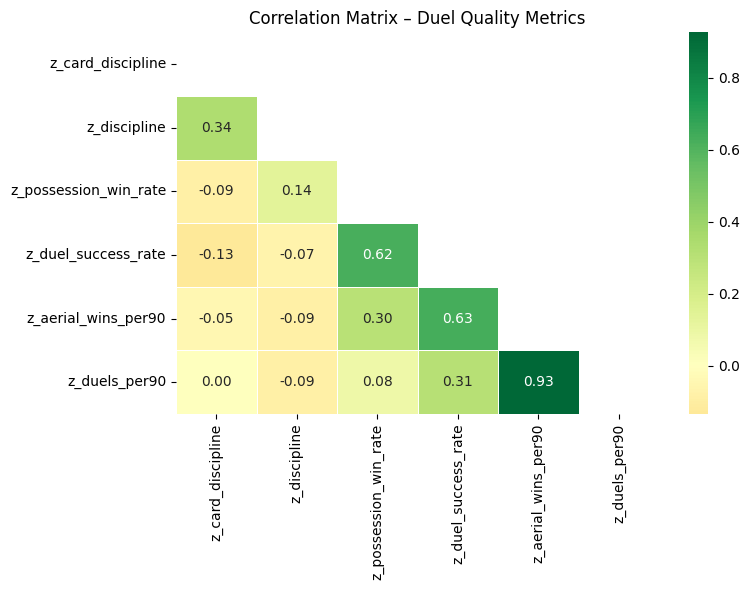

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

corr = z_scores.corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="RdYlGn",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix – Duel Quality Metrics")
plt.tight_layout()
plt.show()


### Visualising Metric Distributions

Before combining metrics into a single score, it is useful to visualise how each normalised metric is distributed across all qualified players. This helps us spot outliers, check that z-scores look reasonable, and understand how spread out player performance is on each dimension. The custom `DistributionPlot` class overlays a highlighted marker for a specific player of interest.


In [60]:
import sys
sys.path.append(str(pathlib.Path().resolve().parents[0]))


In [61]:
metrics = [
    "z_card_discipline",
    "z_discipline",
    "z_possession_win_rate",
    "z_duel_success_rate",
    "z_aerial_wins_per90",
    "z_duels_per90",
]

Quality_Metric_labels = {
    "z_card_discipline": "Card Discipline",
    "z_discipline": "(Overall) Discipline",
    "z_possession_win_rate": "Possession Win Rate",
    "z_duel_success_rate": "Aerial Duel Success Rate",
    "z_aerial_wins_per90": "Aerial Wins per-90",
    "z_duels_per90": "Aerial Duels per-90",
}

Quality_Metric_label_Value_displayed = {
    "z_card_discipline": "card_discipline",
    "z_discipline": "discipline",
    "z_possession_win_rate": "possession_win_rate",
    "z_duel_success_rate": "duel_success_rate",
    "z_aerial_wins_per90": "aerial_wins_per90",
    "z_duels_per90": "duels_per90",
}


In [62]:
from classes.visual import DistributionPlot


# Create distribution plot for z-scores
dist_plot = DistributionPlot(
    columns = metrics,
    labels = ["←  Worse", "Average", "Better  →"],
    quality_metric_labels = Quality_Metric_labels,
    quality_metric_value_columns = Quality_Metric_label_Value_displayed
)

# Add title
dist_plot.add_title(
    title="CB Aerial Duel Quality Distribution",
    subtitle=f"Based on {len(duel_summary)} CB players with ≥{min_num_duels_involved_in_threshold} duels and a playing time ≥{min_minutes_played_threshold} minutes"
)


# Convert z_scores to dataframe format expected by add_group_data
# and merge the raw metric columns so annotation text can show non-z values.
z_scores_df = z_scores.reset_index()

raw_metric_columns = list(dict.fromkeys(Quality_Metric_label_Value_displayed.values()))
missing_raw_metric_columns = [col for col in raw_metric_columns if col not in duel_summary.columns]
if missing_raw_metric_columns:
    raise KeyError(
        "Missing raw metric column(s) required for annotation values: "
        + ", ".join(missing_raw_metric_columns)
    )

raw_metrics_df = duel_summary[raw_metric_columns].reset_index()

z_scores_df = z_scores_df.merge(
    raw_metrics_df,
    on=["player.id", "player.name"],
    how="left",
    validate="one_to_one",
)


# Create hover payload by z-scored metric, containing the raw metric value and the z-score for that metric, to be used in the distribution plot hover annotations
# this allows us to show both the z-score and the actual metric value in the hover tooltip for each player, providing more context and interpretability to the distribution plot.

hover_payload_suffix = "_hover_payload"
hover_string = "%{customdata[0]} = %{customdata[1]:.2f}<br>Respective Z-score = %{customdata[2]:.2f}"

for metric in metrics:
    raw_metric = Quality_Metric_label_Value_displayed.get(metric, metric.replace("z_", "", 1))
    metric_label = Quality_Metric_labels.get(metric, metric)
    z_scores_df[f"{metric}{hover_payload_suffix}"] = list(
        zip(
            [metric_label] * len(z_scores_df),
            z_scores_df[raw_metric],
            pd.to_numeric(z_scores_df[metric], errors="coerce"),
        )
    )


# Add all players as group data (background distribution)
dist_plot.add_group_data(
    df_plot=z_scores_df,
    plots="",  # No suffix needed since columns are already z-scores
    names=z_scores_df["player.name"],
    legend="All players",
    hover=hover_payload_suffix,
    hover_string=hover_string
)


# Highlight/Select a specific player (player.id = 370  ==>  V. van Dijk)
selected_player = z_scores_df[z_scores_df["player.id"] == 370]
if not selected_player.empty:
    player_name = selected_player["player.name"].iloc[0]
    dist_plot.add_data_point(
        ser_plot=selected_player.iloc[0],
        plots="",
        name=player_name,
        hover=hover_payload_suffix,
        hover_string=hover_string,
        add_annotations=True
    )


# Calculate cohort averages (raw metric values & z-scores)
cb_avg_raw_metrics = pd.Series(
    {
        raw_col: pd.to_numeric(z_scores_df[raw_col], errors="coerce").mean()
        for raw_col in raw_metric_columns
    }
)
cb_avg_z_scores = pd.Series(
    {
        z_col: pd.to_numeric(z_scores_df[z_col], errors="coerce").mean()
        for z_col in metrics
    }
)

cb_averages_summary = pd.DataFrame(
    {
        "metric": metrics,
        "avg_metric_value": [cb_avg_raw_metrics.get(Quality_Metric_label_Value_displayed[m], float("nan")) for m in metrics],
        "avg_z_score": [cb_avg_z_scores.get(m, float("nan")) for m in metrics],
    }
)


# Add cohort average as a distinct data point (using averaged z-scores for x-axis position, and raw metric values for hover annotation)

cb_average_point = cb_avg_z_scores.copy()
for metric, raw_metric in Quality_Metric_label_Value_displayed.items():
    cb_average_point[raw_metric] = cb_avg_raw_metrics.get(raw_metric, float("nan"))
for metric in metrics:
    raw_metric = Quality_Metric_label_Value_displayed.get(metric, metric.replace("z_", "", 1))
    metric_label = Quality_Metric_labels.get(metric, metric)
    cb_average_point[f"{metric}{hover_payload_suffix}"] = [
        metric_label,
        cb_average_point.get(raw_metric, float("nan")),
        cb_average_point.get(metric, float("nan")),
    ]

cb_average_point["player.id"] = -1
cb_average_point["player.name"] = "CBs' League Average"


# Add All-CBs average as a distinct data point (using averaged z-scores)
dist_plot.add_data_point(
    ser_plot=cb_average_point,
    plots="",
    name="CBs' League Average",
    hover=hover_payload_suffix,
    hover_string=hover_string,
    add_annotations=False
)

# For Jupyter notebooks, use this to display
dist_plot.fig.show()


In [63]:
from classes.visual import DistributionPlot


# Create distribution plot for z-scores
dist_plot = DistributionPlot(
    columns = metrics,
    labels = ["←  Worse", "Average", "Better  →"],
    quality_metric_labels = Quality_Metric_labels,
    quality_metric_value_columns = Quality_Metric_label_Value_displayed
)

# Add title
dist_plot.add_title(
    title="CB Aerial Duel Quality Distribution",
    subtitle=f"Based on {len(duel_summary)} CB players with ≥{min_num_duels_involved_in_threshold} duels & playing time ≥{min_minutes_played_threshold} minutes"
)

# Convert z_scores to dataframe format expected by add_group_data
# and merge the raw metric columns so annotation text can show non-z values.
z_scores_df = z_scores.reset_index()

raw_metric_columns = list(dict.fromkeys(Quality_Metric_label_Value_displayed.values()))
missing_raw_metric_columns = [col for col in raw_metric_columns if col not in duel_summary.columns]
if missing_raw_metric_columns:
    raise KeyError(
        "Missing raw metric column(s) required for annotation values: "
        + ", ".join(missing_raw_metric_columns)
    )

raw_metrics_df = duel_summary[raw_metric_columns].reset_index()

z_scores_df = z_scores_df.merge(
    raw_metrics_df,
    on=["player.id", "player.name"],
    how="left",
    validate="one_to_one",
)


# Create hover payload by z-scored metric, containing the raw metric value and the z-score for that metric, to be used in the distribution plot hover annotations
# this allows us to show both the z-score and the actual metric value in the hover tooltip for each player, providing more context and interpretability to the distribution plot.

hover_payload_suffix = "_hover_payload"
hover_string = "%{customdata[0]} = %{customdata[1]:.2f}<br>Respective Z-score = %{customdata[2]:.2f}"

for metric in metrics:
    raw_metric = Quality_Metric_label_Value_displayed.get(metric, metric.replace("z_", "", 1))
    metric_label = Quality_Metric_labels.get(metric, metric)
    z_scores_df[f"{metric}{hover_payload_suffix}"] = list(
        zip(
            [metric_label] * len(z_scores_df),
            z_scores_df[raw_metric],
            pd.to_numeric(z_scores_df[metric], errors="coerce"),
        )
    )


# Add all players as group data (background distribution)
dist_plot.add_group_data(
    df_plot=z_scores_df,
    plots="",  # No suffix needed since columns are already z-scores
    names=z_scores_df["player.name"],
    legend="All players",
    hover=hover_payload_suffix,
    hover_string=hover_string
)


# Highlight/Select a specific player (CB #1) --> (ex: player.id = 370  ==> V. van Dijk)
selected_player = z_scores_df[z_scores_df["player.id"] == 370]
if not selected_player.empty:
    player_name = selected_player["player.name"].iloc[0]
    dist_plot.add_data_point(
        ser_plot=selected_player.iloc[0],
        plots="",
        name=player_name,
        hover=hover_payload_suffix,
        hover_string=hover_string,
        add_annotations=True
    )



# Highlight/Select a specific player (CB #2) --> (ex: player.id = 479155  ==>  N. Collins)
selected_player = z_scores_df[z_scores_df["player.id"] == 479155]
if not selected_player.empty:
    player_name = selected_player["player.name"].iloc[0]
    dist_plot.add_data_point(
        ser_plot=selected_player.iloc[0],
        plots="",
        name=player_name,
        hover=hover_payload_suffix,
        hover_string=hover_string,
        add_annotations=True
    )




# Calculate cohort averages (raw metric values & z-scores)
cb_avg_raw_metrics = pd.Series(
    {
        raw_col: pd.to_numeric(z_scores_df[raw_col], errors="coerce").mean()
        for raw_col in raw_metric_columns
    }
)
cb_avg_z_scores = pd.Series(
    {
        z_col: pd.to_numeric(z_scores_df[z_col], errors="coerce").mean()
        for z_col in metrics
    }
)

cb_averages_summary = pd.DataFrame(
    {
        "metric": metrics,
        "avg_metric_value": [cb_avg_raw_metrics.get(Quality_Metric_label_Value_displayed[m], float("nan")) for m in metrics],
        "avg_z_score": [cb_avg_z_scores.get(m, float("nan")) for m in metrics],
    }
)


# 

cb_average_point = cb_avg_z_scores.copy()
for metric, raw_metric in Quality_Metric_label_Value_displayed.items():
    cb_average_point[raw_metric] = cb_avg_raw_metrics.get(raw_metric, float("nan"))
for metric in metrics:
    raw_metric = Quality_Metric_label_Value_displayed.get(metric, metric.replace("z_", "", 1))
    metric_label = Quality_Metric_labels.get(metric, metric)
    cb_average_point[f"{metric}{hover_payload_suffix}"] = [
        metric_label,
        cb_average_point.get(raw_metric, float("nan")),
        cb_average_point.get(metric, float("nan")),
    ]

cb_average_point["player.id"] = -1
cb_average_point["player.name"] = "CBs' League Average"


# Add All-CBs average as a distinct data point (using averaged z-scores)
dist_plot.add_data_point(
    ser_plot=cb_average_point,
    plots="",
    name="CBs' League Average",
    hover=hover_payload_suffix,
    hover_string=hover_string,
    add_annotations=False
)

# For Jupyter notebooks, use this to display
dist_plot.fig.show()


## Quality Score

With all individual metrics normalised, we now aggregate them into a single composite **Aerial Duel Quality Index**. This index captures how well a CB performs across all aerial-duel dimensions — volume, success rate, possession recovery, and discipline — relative to all other qualifying CBs in the dataset.


### Building the Composite Aerial Duel Quality Index

We combine all six normalised metrics into a single weighted score. The (importance) weights reflect the relative importance of each dimension: `possession_win_rate` receives the highest weight (35 %) because directly winning the ball back is the most valuable defensive outcome, while volume and discipline metrics play a supporting role. All (importance) weights sum to 1.0.

**This can be adapted based on our needs**


In [64]:
importance_metric_weights = {
    "z_duels_per90": 0.10,
    "z_aerial_wins_per90": 0.15,
    "z_duel_success_rate": 0.20,
    "z_possession_win_rate": 0.35,
    "z_discipline": 0.10,
    "z_card_discipline": 0.10,
}
if not abs(sum(importance_metric_weights.values()) - 1.0) < 1e-10:
    raise ValueError("(Importance) Weights MUST sum to = 1.0 !")


In [65]:
# Creating the Zq_raw metric as a weighted sum of the z-scores:

# Weighted sum: each metric's z-score is multiplied by its importance weight
duel_summary["Zq_raw"] = sum(
    z_scores[m] * w for m, w in importance_metric_weights.items()
)


### Normalising the Composite Score
### ==>  Creating the Global Aerial Duel Quality Score/Index: `aerial_duel_quality_score`


In [66]:
duel_summary["aerial_duel_quality_score"] = (
    (duel_summary["Zq_raw"] - duel_summary["Zq_raw"].mean())
) / duel_summary["Zq_raw"].std()


### Ranking CBs by Aerial Duel Quality

We now sort all qualified CBs by `aerial_duel_quality_score` in descending order.


In [67]:
duel_summary


,,minutes_played,total_duels,won_possession,won_first_touch,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,...,duels_per90,aerial_wins_per90,z_card_discipline,z_discipline,z_possession_win_rate,z_duel_success_rate,z_aerial_wins_per90,z_duels_per90,Zq_raw,aerial_duel_quality_score
player.id,player.name,,,,,,,,,,,,,,,,,,,,,
479155,N. Collins,3420.0,213,85,42,1,85,0,0,0.596244,0.399061,...,5.605263,3.342105,0.176563,-0.000029,0.198077,0.452527,1.353993,1.360407,0.516625,0.804131
496001,M. Kilman,3349.0,193,83,33,0,77,0,0,0.601036,0.430052,...,5.186623,3.117348,0.176563,0.536806,0.663612,0.517285,1.051564,0.980263,0.662819,1.031682
370,V. van Dijk,3330.0,187,96,39,0,52,0,0,0.721925,0.513369,...,5.054054,3.648649,0.176563,0.536806,1.915178,2.150918,1.766471,0.859884,1.522792,2.370236
192792,D. Burn,3330.0,242,92,54,1,95,0,0,0.603306,0.380165,...,6.540541,3.945946,0.176563,0.064303,-0.085769,0.547954,2.166509,2.209682,0.649603,1.011111
424241,N. Milenković,3330.0,155,61,38,2,54,1,0,0.638710,0.393548,...,4.189189,2.675676,-5.269955,-0.938624,0.115268,1.026385,0.457258,0.074548,-0.299194,-0.465697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234399,A. Webster,901.0,38,15,11,1,11,0,0,0.684211,0.394737,...,3.795782,2.597114,0.176563,-2.472295,0.13312,1.641261,0.351548,-0.282684,0.169735,0.264194
557788,W. Fofana,870.0,36,12,9,1,14,0,0,0.583333,0.333333,...,3.724138,2.172414,0.176563,-2.639467,-0.789266,0.278056,-0.219921,-0.34774,-0.534684,-0.83224
349142,N. Mazraoui,862.0,34,13,3,0,18,0,0,0.470588,0.382353,...,3.549884,1.670534,0.176563,0.536806,-0.052907,-1.245526,-0.895241,-0.505971,-0.381169,-0.593292


In [68]:
# cols = ["aerial_duel_quality_score"]
duel_summary.sort_values("aerial_duel_quality_score", ascending=False).head(15)


,,minutes_played,total_duels,won_possession,won_first_touch,foul,lost_duel,yellow_cards,red_cards,duel_success_rate,possession_win_rate,...,duels_per90,aerial_wins_per90,z_card_discipline,z_discipline,z_possession_win_rate,z_duel_success_rate,z_aerial_wins_per90,z_duels_per90,Zq_raw,aerial_duel_quality_score
player.id,player.name,,,,,,,,,,,,,,,,,,,,,
370,V. van Dijk,3330.0,187,96,39,0,52,0,0,0.721925,0.513369,...,5.054054,3.648649,0.176563,0.536806,1.915178,2.150918,1.766471,0.859884,1.522792,2.370236
62126,M. Doherty,1661.0,74,38,12,0,24,0,0,0.675676,0.513514,...,4.009633,2.709211,0.176563,0.536806,1.91735,1.525926,0.502383,-0.088498,1.114102,1.734107
393247,I. Konaté,2573.0,128,66,14,0,48,0,0,0.625000,0.515625,...,4.477264,2.798290,0.176563,0.536806,1.949068,0.841119,0.622246,0.336133,1.048685,1.632285
620468,J. Greaves,1846.0,111,48,24,1,38,0,0,0.648649,0.432432,...,5.411701,3.510293,0.176563,-0.493336,0.699373,1.160696,1.580302,1.184644,0.800752,1.246376
590781,J. van Hecke,2968.0,163,75,24,0,64,0,0,0.607362,0.460123,...,4.942722,3.002022,0.176563,0.536806,1.115328,0.602768,0.896383,0.75879,0.792592,1.233674
424806,E. Pinnock,1921.0,116,48,26,0,42,0,0,0.637931,0.413793,...,5.434669,3.466944,0.176563,0.536806,0.419378,1.015863,1.521974,1.2055,0.770138,1.198725
578325,W. Saliba,3039.0,97,52,7,0,38,0,0,0.608247,0.536082,...,2.872655,1.747285,0.176563,0.536806,2.256374,0.614733,-0.791965,-1.120925,0.753127,1.172248
623641,E. Agbadou,1411.0,54,27,6,0,21,0,0,0.611111,0.500000,...,3.444366,2.104890,0.176563,0.536806,1.714353,0.653432,-0.310779,-0.601786,0.695251,1.082164
475597,S. Botman,417.0,30,13,3,0,14,0,0,0.533333,0.433333,...,6.474820,3.453237,0.176563,0.536806,0.712906,-0.397619,1.50353,2.150004,0.68186,1.06132


In [69]:
duel_summary["aerial_duel_quality_score"] \
    .sort_values(ascending=False) \
    .head(15)


player.id  player.name 
370        V. van Dijk     2.370236
62126      M. Doherty      1.734107
393247     I. Konaté       1.632285
620468     J. Greaves      1.246376
590781     J. van Hecke    1.233674
424806     E. Pinnock      1.198725
578325     W. Saliba       1.172248
623641     E. Agbadou      1.082164
475597     S. Botman        1.06132
496001     M. Kilman       1.031682
192792     D. Burn         1.011111
8360       C. Dawson       0.998298
145787     J. Andersen     0.886735
136441     B. Davies       0.876018
240032     J. Bednarek     0.838807
Name: aerial_duel_quality_score, dtype: object

In [70]:
duel_summary.columns


Index(['minutes_played', 'total_duels', 'won_possession', 'won_first_touch',
       'foul', 'lost_duel', 'yellow_cards', 'red_cards', 'duel_success_rate',
       'possession_win_rate', 'foul_rate', 'discipline', 'card_discipline',
       'duels_per90', 'aerial_wins_per90', 'z_card_discipline', 'z_discipline',
       'z_possession_win_rate', 'z_duel_success_rate', 'z_aerial_wins_per90',
       'z_duels_per90', 'Zq_raw', 'aerial_duel_quality_score'],
      dtype='object')

In [71]:
aerial_duels_cols = [
    "minutes_played", "total_duels", "yellow_cards", "red_cards",
    "duel_success_rate", "possession_win_rate", "discipline", "card_discipline",
    "duels_per90", "aerial_wins_per90",
    "z_duel_success_rate", "z_possession_win_rate", "z_discipline",
    "z_card_discipline", "z_duels_per90", "z_aerial_wins_per90",
    "aerial_duel_quality_score",
]
df_aerial_duels = duel_summary[aerial_duels_cols].reset_index()
df_aerial_duels.sort_values("aerial_duel_quality_score", ascending=False).head(15)


,player.id,player.name,minutes_played,total_duels,yellow_cards,red_cards,duel_success_rate,possession_win_rate,discipline,card_discipline,duels_per90,aerial_wins_per90,z_duel_success_rate,z_possession_win_rate,z_discipline,z_card_discipline,z_duels_per90,z_aerial_wins_per90,aerial_duel_quality_score
2,370,V. van Dijk,3330.0,187,0,0,0.721925,0.513369,1.000000,1.0,5.054054,3.648649,2.150918,1.915178,0.536806,0.176563,0.859884,1.766471,2.370236
41,62126,M. Doherty,1661.0,74,0,0,0.675676,0.513514,1.000000,1.0,4.009633,2.709211,1.525926,1.91735,0.536806,0.176563,-0.088498,0.502383,1.734107
18,393247,I. Konaté,2573.0,128,0,0,0.625000,0.515625,1.000000,1.0,4.477264,2.798290,0.841119,1.949068,0.536806,0.176563,0.336133,0.622246,1.632285
36,620468,J. Greaves,1846.0,111,0,0,0.648649,0.432432,0.990991,1.0,5.411701,3.510293,1.160696,0.699373,-0.493336,0.176563,1.184644,1.580302,1.246376
11,590781,J. van Hecke,2968.0,163,0,0,0.607362,0.460123,1.000000,1.0,4.942722,3.002022,0.602768,1.115328,0.536806,0.176563,0.75879,0.896383,1.233674
33,424806,E. Pinnock,1921.0,116,0,0,0.637931,0.413793,1.000000,1.0,5.434669,3.466944,1.015863,0.419378,0.536806,0.176563,1.2055,1.521974,1.198725
9,578325,W. Saliba,3039.0,97,0,0,0.608247,0.536082,1.000000,1.0,2.872655,1.747285,0.614733,2.256374,0.536806,0.176563,-1.120925,-0.791965,1.172248
46,623641,E. Agbadou,1411.0,54,0,0,0.611111,0.500000,1.000000,1.0,3.444366,2.104890,0.653432,1.714353,0.536806,0.176563,-0.601786,-0.310779,1.082164
64,475597,S. Botman,417.0,30,0,0,0.533333,0.433333,1.000000,1.0,6.474820,3.453237,-0.397619,0.712906,0.536806,0.176563,2.150004,1.50353,1.06132
1,496001,M. Kilman,3349.0,193,0,0,0.601036,0.430052,1.000000,1.0,5.186623,3.117348,0.517285,0.663612,0.536806,0.176563,0.980263,1.051564,1.031682


In [72]:
file_name = "CB_aerial_duels.csv"
path = os.path.join(str(pathlib.Path().resolve().parents[0]), "data", "data-CB_pairing_AI_analyst", "Qualities", file_name)

df_aerial_duels.to_csv(path, index=False)


## CB Pairings + Companion Fit

The individual CB table (`df_aerial_duels`) is the foundation for pair modelling, but simple pair averaging alone is not sufficient to estimate pair fit robustly. Here we build all unordered CB combinations, explicitly model complementary coverage, and create a directional companion ranking (`A -> B`) to identify who best complements each anchor CB.

(Please feel free to check out the `CB-Pairing AI Analyst - Notebooks\PLAN - Extend CB (Aerial Duels) Analysis to CB-Pairing (Aerial Duels) Analysis.md` file to follow the summarized game-plan of this extended part on the CB-Pairing analysis)


### Build All Unordered Pair Combinations

For each pair we keep:

- pair-level **raw metrics** (mean of both players),

- pair-level **z-metrics** (mean of both players' z-metrics),

- weighted pair components:
  - `quality_raw`   <==>   weighted CB-pair mean: overall quality of the pair based on the average of both players' z-scores for each metric, weighted by importance.
  - `complement_raw`: weighted complement bonus,
  - `floor_raw`: weighted weak-link protection,

- final balanced score (potentially one could allow user-adjustable weights/coefficients for the below formula):
  - `CB_pair_fit_z_score = 0.50*quality_z + 0.30*complement_z + 0.20*floor_z`.


In [73]:
import itertools
import numpy as np
import pandas as pd

cb_players = df_aerial_duels.copy()
cb_players = cb_players.loc[:, ~cb_players.columns.str.startswith("Unnamed:")]
required_identity_cols = ["player.id", "player.name"]
missing_identity_cols = [c for c in required_identity_cols if c not in cb_players.columns]
if missing_identity_cols:
    raise KeyError(f"Missing required identity column(s): {missing_identity_cols}")

z_metric_cols = list(importance_metric_weights.keys())
missing_weight_metrics = [m for m in z_metric_cols if m not in cb_players.columns]
if missing_weight_metrics:
    raise KeyError(f"Weight keys missing from df_aerial_duels: {missing_weight_metrics}")

raw_metric_cols = ["card_discipline", "discipline", "possession_win_rate", "duel_success_rate", "aerial_wins_per90", "duels_per90"]
missing_raw_metrics = [m for m in raw_metric_cols if m not in cb_players.columns]
if missing_raw_metrics:
    raise KeyError(f"Raw metric columns missing from df_aerial_duels: {missing_raw_metrics}")


In [74]:
pair_index = pd.DataFrame(
    list(itertools.combinations(cb_players.index.tolist(), 2)),
    columns=["idx_CB1", "idx_CB2"],
)

CB_pairs_df = (
    pair_index
    .merge(cb_players.add_suffix("_CB1"), left_on="idx_CB1", right_index=True, how="left")
    .merge(cb_players.add_suffix("_CB2"), left_on="idx_CB2", right_index=True, how="left")
)

# Stable unordered key (independent of left/right row order).
CB_pairs_df["pair_id_low"] = np.minimum(CB_pairs_df["player.id_CB1"], CB_pairs_df["player.id_CB2"]).astype(int)
CB_pairs_df["pair_id_high"] = np.maximum(CB_pairs_df["player.id_CB1"], CB_pairs_df["player.id_CB2"]).astype(int)
CB_pairs_df["pair_key"] = CB_pairs_df["pair_id_low"].astype(str) + "__" + CB_pairs_df["pair_id_high"].astype(str)

CB_pairs_df["pair_name"] = CB_pairs_df["player.name_CB1"] + " + " + CB_pairs_df["player.name_CB2"]


In [75]:
# Pair-level raw metrics: equal-weight average between the two players.

for col in raw_metric_cols:
    CB_pairs_df[col] = (CB_pairs_df[f"{col}_CB1"] + CB_pairs_df[f"{col}_CB2"]) / 2.0



# Pair-level z-metrics (same naming convention) = mean of both players' z-score values.

for z_col in z_metric_cols:
    pair_mean_col = f"{z_col}_pair_mean"
    pair_best_col = f"{z_col}_pair_best"
    pair_floor_col = f"{z_col}_pair_floor"

    CB_pairs_df[pair_mean_col] = (CB_pairs_df[f"{z_col}_CB1"] + CB_pairs_df[f"{z_col}_CB2"]) / 2.0
    CB_pairs_df[pair_best_col] = np.maximum(CB_pairs_df[f"{z_col}_CB1"], CB_pairs_df[f"{z_col}_CB2"])
    CB_pairs_df[pair_floor_col] = np.minimum(CB_pairs_df[f"{z_col}_CB1"], CB_pairs_df[f"{z_col}_CB2"])

    # DistributionPlot-friendly z column names.

    CB_pairs_df[z_col] = CB_pairs_df[pair_mean_col]




## Weighted CB-Pair components:


# quality_raw = Σ w_m * pair_mean_m   <==>   weighted CB-pair mean: overall quality of the pair based on the average of both players' z-scores for each metric, weighted by importance.

CB_pairs_df["quality_raw"] = sum(
    importance_metric_weights[z_col] * CB_pairs_df[f"{z_col}_pair_mean"]
    for z_col in z_metric_cols
)


# complement_raw = Σ w_m * (pair_best_m - pair_mean_m)   <==>   coverage/complement bonus: how well the two players' strengths complement each other (e.g. one is strong in metric A, the other in metric B, so they cover more quality dimensions as a pair).

CB_pairs_df["complement_raw"] = sum(
    importance_metric_weights[z_col] * (CB_pairs_df[f"{z_col}_pair_best"] - CB_pairs_df[f"{z_col}_pair_mean"])
    for z_col in z_metric_cols
)


# floor_raw = Σ w_m * pair_floor_m   <==>   weak-link protection: floor quality of the pair based on the weaker player's z-score for each metric, weighted by importance. This captures the idea that a pair is only as strong as its weaker link in each dimension.

CB_pairs_df["floor_raw"] = sum(
    importance_metric_weights[z_col] * CB_pairs_df[f"{z_col}_pair_floor"]
    for z_col in z_metric_cols
)


# Standardize the raw pair quality components to get z-scores for each component, which can then be combined into an overall CB-Pair Fit-score.

def Z_standardize(series: pd.Series) -> pd.Series:
    """
    Standardize a pandas Series to have mean = 0 and std = 1 (z-score).
    Handles zero or NaN std by returning a series of zeros.
    """
    std = series.std()
    if std == 0 or np.isnan(std):
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.mean()) / std


CB_pairs_df["quality_z"] = Z_standardize(CB_pairs_df["quality_raw"])
CB_pairs_df["complement_z"] = Z_standardize(CB_pairs_df["complement_raw"])
CB_pairs_df["floor_z"] = Z_standardize(CB_pairs_df["floor_raw"])


In [76]:
# Balanced CB-Pair Fit z-score   (potentially one could allow user-adjustable weights/coefficients for the below formula)

quality_z_coeff = 0.50
complement_z_coeff = 0.30
floor_z_coeff = 0.20


CB_pairs_df["CB_pair_fit_z_score"] = (
    quality_z_coeff * CB_pairs_df["quality_z"] +
    complement_z_coeff * CB_pairs_df["complement_z"] +
    floor_z_coeff * CB_pairs_df["floor_z"]
)


# Rank CB-Pairs by their Balanced CB-Pair Fit z-score (descending, so best fit gets ranked 1st). Use "min" method to assign the same rank to ties (i.e. if two pairs have the same fit z-score, they get the same rank), and convert to integer type.

CB_pairs_df["CB_pair_fit_rank"] = ( CB_pairs_df["CB_pair_fit_z_score"].rank(ascending=False, method="min").astype(int) )



In [77]:
# Display the top 20 CB-Pairs by their Balanced CB-Pair Fit z-score, along with their pair name, individual player names, and the quality/complement/floor z-scores that contribute to the overall fit score.

CB_pairs_df[[
    "pair_key",
    "pair_name",
    "player.id_CB1", "player.name_CB1",
    "player.id_CB2", "player.name_CB2",
    "CB_pair_fit_z_score", "CB_pair_fit_rank",
    "quality_z", "complement_z", "floor_z",
]].sort_values("CB_pair_fit_z_score", ascending=False).head(20)


,pair_key,pair_name,player.id_CB1,player.name_CB1,player.id_CB2,player.name_CB2,CB_pair_fit_z_score,CB_pair_fit_rank,quality_z,complement_z,floor_z
127,370__192792,V. van Dijk + D. Burn,370,V. van Dijk,192792,D. Burn,1.725753,1,2.428045,0.488848,1.825379
133,370__578325,V. van Dijk + W. Saliba,370,V. van Dijk,578325,W. Saliba,1.686624,2,2.543753,-0.058534,2.161539
165,370__62126,V. van Dijk + M. Doherty,370,V. van Dijk,62126,M. Doherty,1.682604,3,2.947207,-1.344547,3.061824
188,370__475597,V. van Dijk + S. Botman,370,V. van Dijk,475597,S. Botman,1.67477,4,2.464099,0.135896,2.009761
142,370__393247,V. van Dijk + I. Konaté,370,V. van Dijk,393247,I. Konaté,1.673822,5,2.874091,-1.15621,2.918196
172,370__136441,V. van Dijk + B. Davies,370,V. van Dijk,136441,B. Davies,1.645175,6,2.331039,0.414632,1.776328
160,370__620468,V. van Dijk + J. Greaves,370,V. van Dijk,620468,J. Greaves,1.620917,7,2.596982,-0.534663,2.414126
157,370__424806,V. van Dijk + E. Pinnock,370,V. van Dijk,424806,E. Pinnock,1.613964,8,2.562765,-0.459893,2.352747
135,370__590781,V. van Dijk + J. van Hecke,370,V. van Dijk,590781,J. van Hecke,1.588863,9,2.587861,-0.656735,2.459767
64,370__496001,M. Kilman + V. van Dijk,496001,M. Kilman,370,V. van Dijk,1.562313,10,2.442817,-0.326042,2.193584


In [78]:
# Display the bottom/worse 20 CB-Pairs by their Balanced CB-Pair Fit z-score, along with their pair name, individual player names, and the quality/complement/floor z-scores that contribute to the overall fit score.

CB_pairs_df[[
    "pair_key",
    "pair_name",
    "player.id_CB1", "player.name_CB1",
    "player.id_CB2", "player.name_CB2",
    "CB_pair_fit_z_score", "CB_pair_fit_rank",
    "quality_z", "complement_z", "floor_z",
]].sort_values("CB_pair_fit_z_score", ascending=True).head(20)


,pair_key,pair_name,player.id_CB1,player.name_CB1,player.id_CB2,player.name_CB2,CB_pair_fit_z_score,CB_pair_fit_rank,quality_z,complement_z,floor_z
1730,7953__488453,C. Coady + L. Martínez,7953,C. Coady,488453,L. Martínez,-2.183494,2080,-2.746826,-1.639969,-1.590451
1527,297957__488453,M. Akanji + L. Martínez,297957,M. Akanji,488453,L. Martínez,-2.157336,2079,-2.847635,-1.20037,-1.86704
1791,488453__518805,L. Martínez + L. Woolfenden,488453,L. Martínez,518805,L. Woolfenden,-2.120578,2078,-2.861156,-0.985069,-1.972399
1506,400549__518805,Pau Torres + L. Woolfenden,400549,Pau Torres,518805,L. Woolfenden,-2.111006,2077,-2.58336,-1.81252,-1.377849
1494,400549__488453,Pau Torres + L. Martínez,400549,Pau Torres,488453,L. Martínez,-2.091695,2076,-2.743286,-1.219449,-1.771088
1492,7953__400549,Pau Torres + C. Coady,400549,Pau Torres,7953,C. Coady,-2.000209,2075,-2.469031,-1.650622,-1.352536
1742,7953__518805,C. Coady + L. Woolfenden,7953,C. Coady,518805,L. Woolfenden,-1.990942,2074,-2.586901,-1.23686,-1.63217
1539,297957__518805,M. Akanji + L. Woolfenden,297957,M. Akanji,518805,L. Woolfenden,-1.982132,2073,-2.687709,-0.878831,-1.873142
1485,297957__400549,Pau Torres + M. Akanji,400549,Pau Torres,297957,M. Akanji,-1.913462,2072,-2.569839,-0.926131,-1.753515
1525,7953__297957,M. Akanji + C. Coady,297957,M. Akanji,7953,C. Coady,-1.881384,2071,-2.57338,-0.764181,-1.827199


### Add Realism Metadata (Not Used in Scoring)

We enrich each pair with context columns to support practical filtering and interpretation:

- dominant team/side assignment per player,
- same-team and opposite-side indicators,
- shared match count and shared on-pitch overlap minutes,
- evidence band derived from shared overlap.


In [79]:
# Build player dominant team and dominant side metadata from the minutes.parquet data:


cb_possible_positions = ["CB", "LCB", "RCB", "LCB3", "RCB3"]

minutes_cb = minutes_england_df[
    minutes_england_df["position_provider"].isin(cb_possible_positions)
].copy()

qualified_ids = set(cb_players["player.id"].astype(int).tolist())
minutes_cb = minutes_cb[minutes_cb["player_id"].isin(qualified_ids)].copy()


In [80]:
# Calculate total minutes played in CB positions for each player-team combination:
# This will help identify the dominant team for each player based on where they played the most minutes as a CB - we group by both player_id and team_id to get the total minutes for each player at each team they played for in a CB position.

team_minutes = (
    minutes_cb
    .groupby(["player_id", "team_id"], as_index=False)["minutes_played"]
    .sum()
)


# Dominant team = team with most CB minutes:
# We use idxmax to find the index of the team with the maximum minutes for each player, and then select those rows to get the dominant team_id for each player. We rename the column to "dominant_team_id" for clarity.

dominant_team = team_minutes.loc[
    team_minutes.groupby("player_id")["minutes_played"].idxmax(),
    ["player_id", "team_id"]
].rename(columns={"team_id": "dominant_team_id"})


In [81]:
# Map specific CB positions to general sides (left, right, center) for dominant side analysis:
# This will help identify the dominant side for each player based on where they played the most minutes as a CB - we group by both player_id and position_provider to get the total minutes for each player at each CB position, and then find the position with the maximum minutes to determine the dominant side.

CB_position_side_map = {
    "LCB": "left",
    "LCB3": "left",
    "RCB": "right",
    "RCB3": "right",
    "CB": "center",
}

CB_side_minutes_played = (
    minutes_cb
    .groupby(["player_id", "position_provider"], as_index=False)["minutes_played"]
    .sum()
)

CB_dominant_playing_side = CB_side_minutes_played.loc[
    CB_side_minutes_played.groupby("player_id")["minutes_played"].idxmax(),
    ["player_id", "position_provider"]
].rename(columns={"position_provider": "dominant_position_provider"})

CB_dominant_playing_side["CB_dominant_playing_side"] = CB_dominant_playing_side["dominant_position_provider"].map(CB_position_side_map)

player_meta = (
    cb_players[["player.id", "player.name"]]
    .drop_duplicates()
    .rename(columns={"player.id": "player_id", "player.name": "player_name"})
    .merge(dominant_team, on="player_id", how="left")
    .merge(CB_dominant_playing_side[["player_id", "CB_dominant_playing_side", "dominant_position_provider"]], on="player_id", how="left")
)


In [82]:
# Shared on-pitch overlap minutes:
# This is a key real-world validation metric for the CB-Pair Fit z-score, as it shows how much actual playing time the 2 players had together on the pitch in the same match AND team, which is crucial for assessing their potential chemistry and fit as a pair - we calculate this by determining the minutes played for each player in each match, and then computing the overlap in minutes between pairs of players who were on the same team in the same match.


# We start by creating a base DataFrame with the relevant columns from the minutes_cb DataFrame, and then calculate the start and end minutes for each player's time on the pitch in each match
# we handle cases where sub_out is missing or invalid by using the sub_in time plus the total minutes played, and we also clip the end minute to a maximum of 130 to account for extra time.

overlap_base = minutes_cb[[
    "match_id", "team_id", "player_id", "sub_in", "sub_out", "minutes_played"
]].copy()

overlap_base["start_min"] = overlap_base["sub_in"].fillna(0)
overlap_base["end_min"] = overlap_base["sub_out"]

invalid_end = overlap_base["end_min"].isna() | (overlap_base["end_min"] <= overlap_base["start_min"])
overlap_base.loc[invalid_end, "end_min"] = (
    overlap_base.loc[invalid_end, "start_min"] + overlap_base.loc[invalid_end, "minutes_played"]
)

overlap_base["end_min"] = overlap_base["end_min"].clip(upper=130)

pair_overlap_rows = []
for (match_id, team_id), grp in overlap_base.groupby(["match_id", "team_id"]):
    grp = grp[["player_id", "start_min", "end_min"]].drop_duplicates(subset=["player_id"])
    vals = grp.to_numpy()

    for i in range(len(vals)):
        for j in range(i + 1, len(vals)):
            player_CB1, start_CB1, end_CB1 = vals[i]
            player_CB2, start_CB2, end_CB2 = vals[j]

            pair_low = int(min(player_CB1, player_CB2))
            pair_high = int(max(player_CB1, player_CB2))

            overlap = max(0.0, min(end_CB1, end_CB2) - max(start_CB1, start_CB2))
            pair_overlap_rows.append((pair_low, pair_high, int(match_id), int(team_id), float(overlap)))

pair_overlap = pd.DataFrame(
    pair_overlap_rows,
    columns=["pair_id_low", "pair_id_high", "match_id", "team_id", "overlap_minutes"],
)

if pair_overlap.empty:
    overlap_summary = pd.DataFrame(columns=["pair_id_low", "pair_id_high", "shared_matches", "shared_minutes_overlap"])
else:
    overlap_positive = pair_overlap[pair_overlap["overlap_minutes"] > 0]
    overlap_summary = (
        overlap_positive
        .groupby(["pair_id_low", "pair_id_high"], as_index=False)
        .agg(
            shared_matches=("match_id", "nunique"),
            shared_minutes_overlap=("overlap_minutes", "sum"),
        )
    )


# Merge the CB pairs DataFrame with player metadata and the overlap summary to enrich the pairs with information about their dominant teams, sides, and actual shared playing time on the pitch, which will be crucial for validating the CB-Pair Fit z-score against real-world data on how much these pairs actually played together.

CB_pairs_df = (
    CB_pairs_df
    .merge(
        player_meta.rename(columns={
            "player_id": "player.id_CB1",
            "player_name": "player.name_CB1_meta",
            "dominant_team_id": "team_CB1_id",
            "CB_dominant_playing_side": "CB_dominant_playing_side_CB1",
            "dominant_position_provider": "dominant_position_provider_CB1",
        }),
        on="player.id_CB1",
        how="left",
    )
    .merge(
        player_meta.rename(columns={
            "player_id": "player.id_CB2",
            "player_name": "player.name_CB2_meta",
            "dominant_team_id": "team_CB2_id",
            "CB_dominant_playing_side": "CB_dominant_playing_side_CB2",
            "dominant_position_provider": "dominant_position_provider_CB2",
        }),
        on="player.id_CB2",
        how="left",
    )
    .merge(overlap_summary, on=["pair_id_low", "pair_id_high"], how="left")
)


# Handle missing values for shared_matches and shared_minutes_overlap (which can occur if a pair never played together in the same match) by filling with 0

CB_pairs_df["shared_matches"] = CB_pairs_df["shared_matches"].fillna(0).astype(int)
CB_pairs_df["shared_minutes_overlap"] = CB_pairs_df["shared_minutes_overlap"].fillna(0.0)


# Create additional metadata columns to indicate if the pair had the same dominant team, if they played on opposite sides

CB_pairs_df["same_dominant_team"] = (
    CB_pairs_df["team_CB1_id"].notna() &
    CB_pairs_df["team_CB2_id"].notna() &
    (CB_pairs_df["team_CB1_id"] == CB_pairs_df["team_CB2_id"])
)

CB_pairs_df["opposite_side_pair"] = (
    ((CB_pairs_df["CB_dominant_playing_side_CB1"] == "left") & (CB_pairs_df["CB_dominant_playing_side_CB2"] == "right")) |
    ((CB_pairs_df["CB_dominant_playing_side_CB1"] == "right") & (CB_pairs_df["CB_dominant_playing_side_CB2"] == "left"))
)


# Categorize their shared minutes overlap into evidence bands for fit validation:
# This will help us analyze how the CB-Pair Fit z-score correlates with actual shared playing time, which is a key real-world validation of the fit score - we use pd.cut to create categorical bands based on the distribution of shared minutes overlap, with thresholds that can be adjusted based on the data distribution.

CB_pairs_df["evidence_band"] = pd.cut(
    CB_pairs_df["shared_minutes_overlap"],
    bins=[-0.1, 0, 180, 450, 900, np.inf],
    labels=["none", "low", "medium", "high", "very_high"],
)

CB_pairs_df["evidence_band"] = CB_pairs_df["evidence_band"].astype(str)



In [83]:
# Finally, display the top 20 CB-Pairs by their Balanced CB-Pair Fit z-score, along with their pair name, fit z-score, metadata on dominant teams/sides, shared matches/minutes, and evidence band for real-world fit validation.

CB_pairs_df[[
    "pair_name",
    "CB_pair_fit_z_score",
    "same_dominant_team",
    "opposite_side_pair",
    "shared_matches",
    "shared_minutes_overlap",
    "evidence_band",
]].sort_values("CB_pair_fit_z_score", ascending=False).head(20)


,pair_name,CB_pair_fit_z_score,same_dominant_team,opposite_side_pair,shared_matches,shared_minutes_overlap,evidence_band
127,V. van Dijk + D. Burn,1.725753,False,False,0,0.0,none
133,V. van Dijk + W. Saliba,1.686624,False,True,0,0.0,none
165,V. van Dijk + M. Doherty,1.682604,False,True,0,0.0,none
188,V. van Dijk + S. Botman,1.67477,False,True,0,0.0,none
142,V. van Dijk + I. Konaté,1.673822,True,True,30,2475.0,very_high
172,V. van Dijk + B. Davies,1.645175,False,False,0,0.0,none
160,V. van Dijk + J. Greaves,1.620917,False,False,0,0.0,none
157,V. van Dijk + E. Pinnock,1.613964,False,False,0,0.0,none
135,V. van Dijk + J. van Hecke,1.588863,False,True,0,0.0,none
64,M. Kilman + V. van Dijk,1.562313,False,False,0,0.0,none


### Build Directional Companion Fit (`A -> B`)

Global pair fit is symmetric, but companion choice is directional. For each anchor CB `A`, we compute deficits on each weighted z-metric and quantify how much partner `B` covers those deficits. We then blend this deficit-coverage signal with the global `CB_pair_fit_z_score`.


In [84]:
player_lookup_cols = ["player.id", "player.name", "aerial_duel_quality_score"] + raw_metric_cols + z_metric_cols
players_lookup = cb_players[player_lookup_cols].copy()
pair_fit_lookup = CB_pairs_df[["pair_key", "CB_pair_fit_z_score"]].copy()

player_rows = players_lookup[["player.id", "player.name"]].drop_duplicates()
ordered_pairs = (
    player_rows.rename(columns={"player.id": "anchor_player_id", "player.name": "anchor_player_name"})
    .assign(_key=1)
    .merge(player_rows.rename(columns={"player.id": "partner_player_id", "player.name": "partner_player_name"}).assign(_key=1), on="_key", how="inner")
    .drop(columns=["_key"])
)
ordered_pairs = ordered_pairs[ordered_pairs["anchor_player_id"] != ordered_pairs["partner_player_id"]].copy()

ordered_pairs = (
    ordered_pairs
    .merge(players_lookup.add_prefix("anchor_"), left_on="anchor_player_id", right_on="anchor_player.id", how="left")
    .merge(players_lookup.add_prefix("partner_"), left_on="partner_player_id", right_on="partner_player.id", how="left")
)

ordered_pairs["pair_id_low"] = np.minimum(ordered_pairs["anchor_player_id"], ordered_pairs["partner_player_id"]).astype(int)
ordered_pairs["pair_id_high"] = np.maximum(ordered_pairs["anchor_player_id"], ordered_pairs["partner_player_id"]).astype(int)
ordered_pairs["pair_key"] = ordered_pairs["pair_id_low"].astype(str) + "__" + ordered_pairs["pair_id_high"].astype(str)
ordered_pairs = ordered_pairs.merge(pair_fit_lookup, on="pair_key", how="left")


In [85]:
# Deficit-Coverage Gain - partner positive z values covering anchor negative deficits:
# i.e. For each metric, calculate the anchor's deficit (if any) and the partner's coverage towards that deficit, then combine these into an overall coverage gain score for the pair. This captures how well the partner's strengths can compensate for the anchor's weaknesses in each metric dimension, which is a key aspect of their potential fit as a pair
# we calculate the deficit as the negative of the anchor's z-score (if it's negative, otherwise 0), and the coverage as the minimum of the deficit and the partner's positive z-score (if it's positive, otherwise 0), then we sum these coverage values across all metrics weighted by importance to get an overall coverage gain score for the pair.

deficit_cols = []
coverage_cols = []

for z_col in z_metric_cols:
    deficit_col = f"anchor_deficit_{z_col}"
    coverage_col = f"coverage_{z_col}"

    ordered_pairs[deficit_col] = np.maximum(0.0, -ordered_pairs[f"anchor_{z_col}"])
    ordered_pairs[coverage_col] = np.minimum(
        ordered_pairs[deficit_col],
        np.maximum(0.0, ordered_pairs[f"partner_{z_col}"])
    )

    deficit_cols.append(deficit_col)
    coverage_cols.append(coverage_col)

ordered_pairs["coverage_gain_raw"] = sum(
    importance_metric_weights[z_col] * ordered_pairs[f"coverage_{z_col}"]
    for z_col in z_metric_cols
)


# Standardize Deficit-Coverage Gain within each anchor (directional comparison context)

coverage_group_mean = ordered_pairs.groupby("anchor_player_id")["coverage_gain_raw"].transform("mean")
coverage_group_std = ordered_pairs.groupby("anchor_player_id")["coverage_gain_raw"].transform("std")
coverage_group_std = coverage_group_std.replace(0, np.nan)

ordered_pairs["coverage_gain_z_within_anchor"] = (
    (ordered_pairs["coverage_gain_raw"] - coverage_group_mean) / coverage_group_std
).fillna(0.0)


In [86]:
# Now blend/combine this Deficit-Coverage gain/signal with the previously calculated global `CB_pair_fit_z_score`
# This allows us to incorporate both the overall pair quality (`CB_pair_fit_z_score`) and the specific complementary fit between the anchor and partner (`coverage_gain_z_within_anchor`) into a single companion fit score that can be used to rank potential companions for each anchor player.

overall_CB_pair_quality_fit_weight = 0.65                    # (potentially one could allow user-adjustable weights/coefficients for the below formula)
deficit_coverage_complementary_fit_weight = 0.35             # (potentially one could allow user-adjustable weights/coefficients for the below formula)


ordered_pairs["companion_fit_score"] = (
    overall_CB_pair_quality_fit_weight * ordered_pairs["CB_pair_fit_z_score"] +
    deficit_coverage_complementary_fit_weight * ordered_pairs["coverage_gain_z_within_anchor"]
)


# Rank potential companions for each anchor player based on the companion fit score, so that for each anchor, we can identify which partners are the best fit as a pair according to our combined fit metric
# We sort by anchor_player_id and companion_fit_score (descending), and then assign a rank within each anchor group.

ordered_pairs = ordered_pairs.sort_values(
    ["anchor_player_id", "companion_fit_score", "partner_player_name"],
    ascending=[True, False, True],
)

ordered_pairs["companion_rank_for_anchor"] = (
    ordered_pairs.groupby("anchor_player_id").cumcount() + 1
)


In [87]:
df_aerial_duel_companion_fit = ordered_pairs[[
    "anchor_player_id", "anchor_player_name", "partner_player_id", "partner_player_name",
    "CB_pair_fit_z_score", "coverage_gain_raw", "coverage_gain_z_within_anchor",
    "companion_fit_score", "companion_rank_for_anchor",
]].copy()

df_aerial_duel_companion_fit["pair_key"] = (
    np.minimum(df_aerial_duel_companion_fit["anchor_player_id"], df_aerial_duel_companion_fit["partner_player_id"]).astype(str)
    + "__" +
    np.maximum(df_aerial_duel_companion_fit["anchor_player_id"], df_aerial_duel_companion_fit["partner_player_id"]).astype(str)
)

anchor_player_name = cb_players.sort_values("aerial_duel_quality_score", ascending=False)["player.name"].iloc[0]
df_aerial_duel_companion_fit[df_aerial_duel_companion_fit["anchor_player_name"] == anchor_player_name].head(10)


,anchor_player_id,anchor_player_name,partner_player_id,partner_player_name,CB_pair_fit_z_score,coverage_gain_raw,coverage_gain_z_within_anchor,companion_fit_score,companion_rank_for_anchor,pair_key
130,370,V. van Dijk,192792,D. Burn,1.725753,0.0,0.0,1.121739,1,370__192792
136,370,V. van Dijk,578325,W. Saliba,1.686624,0.0,0.0,1.096306,2,370__578325
168,370,V. van Dijk,62126,M. Doherty,1.682604,0.0,0.0,1.093693,3,370__62126
191,370,V. van Dijk,475597,S. Botman,1.67477,0.0,0.0,1.088601,4,370__475597
145,370,V. van Dijk,393247,I. Konaté,1.673822,0.0,0.0,1.087984,5,370__393247
175,370,V. van Dijk,136441,B. Davies,1.645175,0.0,0.0,1.069363,6,370__136441
163,370,V. van Dijk,620468,J. Greaves,1.620917,0.0,0.0,1.053596,7,370__620468
160,370,V. van Dijk,424806,E. Pinnock,1.613964,0.0,0.0,1.049077,8,370__424806
138,370,V. van Dijk,590781,J. van Hecke,1.588863,0.0,0.0,1.032761,9,370__590781
129,370,V. van Dijk,496001,M. Kilman,1.562313,0.0,0.0,1.015503,10,370__496001


### Final Pair and Companion DataFrames + CSV Export


In [88]:
pair_output_cols = [
    "pair_key", "pair_name",
    "player.id_CB1", "player.name_CB1",
    "player.id_CB2", "player.name_CB2",
    "card_discipline", "discipline", "possession_win_rate", "duel_success_rate", "aerial_wins_per90", "duels_per90",
    "z_card_discipline", "z_discipline", "z_possession_win_rate", "z_duel_success_rate", "z_aerial_wins_per90", "z_duels_per90",
    "quality_raw", "complement_raw", "floor_raw",
    "quality_z", "complement_z", "floor_z",
    "CB_pair_fit_z_score", "CB_pair_fit_rank",
    "team_CB1_id", "team_CB2_id", "same_dominant_team",
    "CB_dominant_playing_side_CB1", "CB_dominant_playing_side_CB2", "opposite_side_pair",
    "shared_matches", "shared_minutes_overlap", "evidence_band",
]
df_aerial_duel_pairs = CB_pairs_df[pair_output_cols].copy()
df_aerial_duel_pairs = df_aerial_duel_pairs.sort_values("CB_pair_fit_z_score", ascending=False).reset_index(drop=True)
df_aerial_duel_pairs.head(20)


,pair_key,pair_name,player.id_CB1,player.name_CB1,player.id_CB2,player.name_CB2,card_discipline,discipline,possession_win_rate,duel_success_rate,...,CB_pair_fit_rank,team_CB1_id,team_CB2_id,same_dominant_team,CB_dominant_playing_side_CB1,CB_dominant_playing_side_CB2,opposite_side_pair,shared_matches,shared_minutes_overlap,evidence_band
0,370__192792,V. van Dijk + D. Burn,370,V. van Dijk,192792,D. Burn,1.0,0.997934,0.446767,0.662615,...,1,1612,1613,False,left,left,False,0,0.0,none
1,370__578325,V. van Dijk + W. Saliba,370,V. van Dijk,578325,W. Saliba,1.0,1.000000,0.524726,0.665086,...,2,1612,1609,False,left,right,True,0,0.0,none
2,370__62126,V. van Dijk + M. Doherty,370,V. van Dijk,62126,M. Doherty,1.0,1.000000,0.513441,0.698800,...,3,1612,1629,False,left,right,True,0,0.0,none
3,370__475597,V. van Dijk + S. Botman,370,V. van Dijk,475597,S. Botman,1.0,1.000000,0.473351,0.627629,...,4,1612,1613,False,left,right,True,0,0.0,none
4,370__393247,V. van Dijk + I. Konaté,370,V. van Dijk,393247,I. Konaté,1.0,1.000000,0.514497,0.673463,...,5,1612,1612,True,left,right,True,30,2475.0,very_high
5,370__136441,V. van Dijk + B. Davies,370,V. van Dijk,136441,B. Davies,1.0,1.000000,0.465868,0.621167,...,6,1612,1624,False,left,left,False,0,0.0,none
6,370__620468,V. van Dijk + J. Greaves,370,V. van Dijk,620468,J. Greaves,1.0,0.995495,0.472901,0.685287,...,7,1612,1634,False,left,left,False,0,0.0,none
7,370__424806,V. van Dijk + E. Pinnock,370,V. van Dijk,424806,E. Pinnock,1.0,1.000000,0.463581,0.679928,...,8,1612,1669,False,left,left,False,0,0.0,none
8,370__590781,V. van Dijk + J. van Hecke,370,V. van Dijk,590781,J. van Hecke,1.0,1.000000,0.486746,0.664644,...,9,1612,1651,False,left,right,True,0,0.0,none
9,370__496001,M. Kilman + V. van Dijk,496001,M. Kilman,370,V. van Dijk,1.0,1.000000,0.471710,0.661481,...,10,1633,1612,False,left,left,False,0,0.0,none


In [89]:
qualities_dir = os.path.join(str(pathlib.Path().resolve().parents[0]), "data", "data-CB_pairing_AI_analyst", "Qualities")
CB_pairs_file_name = "CB_aerial_duel_pairs.csv"
CB_companion_file_name = "CB_aerial_duel_companion_fit.csv"
df_aerial_duel_pairs.to_csv(os.path.join(qualities_dir, CB_pairs_file_name), index=False)
df_aerial_duel_companion_fit.to_csv(os.path.join(qualities_dir, CB_companion_file_name), index=False)
print(f"Saved: {CB_pairs_file_name} ({len(df_aerial_duel_pairs)} rows)")
print(f"Saved: {CB_companion_file_name} ({len(df_aerial_duel_companion_fit)} rows)")


Saved: CB_aerial_duel_pairs.csv (2080 rows)
Saved: CB_aerial_duel_companion_fit.csv (4160 rows)


### Validation Checks

The assertions below verify counts, schema integrity, uniqueness/symmetry, and ranking behavior.


In [90]:
n_players = len(cb_players)
expected_pair_count = n_players * (n_players - 1) // 2
expected_companion_count = n_players * (n_players - 1)
assert len(df_aerial_duel_pairs) == expected_pair_count, f"Pair count mismatch: {len(df_aerial_duel_pairs)} != {expected_pair_count}"
assert len(df_aerial_duel_companion_fit) == expected_companion_count, f"Companion count mismatch: {len(df_aerial_duel_companion_fit)} != {expected_companion_count}"
score_cols = ["quality_raw", "complement_raw", "floor_raw", "quality_z", "complement_z", "floor_z", "CB_pair_fit_z_score"]
assert not df_aerial_duel_pairs[score_cols].isna().any().any(), "NaN detected in pair score columns"
assert not df_aerial_duel_companion_fit[["CB_pair_fit_z_score", "coverage_gain_raw", "coverage_gain_z_within_anchor", "companion_fit_score"]].isna().any().any(), "NaN detected in companion score columns"
assert df_aerial_duel_pairs["pair_key"].nunique() == len(df_aerial_duel_pairs), "Duplicate unordered pair keys found"
comp_forward = df_aerial_duel_companion_fit[["anchor_player_id", "partner_player_id", "CB_pair_fit_z_score"]].copy()
comp_reverse = comp_forward.rename(columns={"anchor_player_id": "partner_player_id", "partner_player_id": "anchor_player_id", "CB_pair_fit_z_score": "CB_pair_fit_score_reverse"})
comp_sym = comp_forward.merge(comp_reverse, on=["anchor_player_id", "partner_player_id"], how="left")
max_sym_diff = (comp_sym["CB_pair_fit_z_score"] - comp_sym["CB_pair_fit_score_reverse"]).abs().max()
assert max_sym_diff < 1e-12, f"Pair symmetry broken, max diff = {max_sym_diff}"
rank_check = df_aerial_duel_companion_fit.groupby("anchor_player_id")["companion_rank_for_anchor"]
assert rank_check.nunique().eq(n_players - 1).all(), "Duplicate companion ranks detected within at least one anchor"
assert rank_check.min().eq(1).all(), "Companion ranks do not start at 1 for at least one anchor"
assert rank_check.max().eq(n_players - 1).all(), "Companion ranks do not end at n-1 for at least one anchor"
assert abs(sum(importance_metric_weights.values()) - 1.0) < 1e-10, "importance_metric_weights must sum to 1"
missing_weight_metrics_after_build = [m for m in importance_metric_weights.keys() if m not in df_aerial_duel_pairs.columns]
assert not missing_weight_metrics_after_build, f"Missing weighted z-metric(s) in pair table: {missing_weight_metrics_after_build}"
print("All validation checks passed.")
print(f"Players: {n_players}")
print(f"Pairs: {len(df_aerial_duel_pairs)}")
print(f"Directional companion rows: {len(df_aerial_duel_companion_fit)}")


All validation checks passed.
Players: 65
Pairs: 2080
Directional companion rows: 4160


### Visual Compatibility Check (`DistributionPlot` from `visual.py`)

This cell uses pair z-metrics and maps annotation labels to pair raw values to confirm compatibility with the `DistributionPlot` interface.


In [91]:
import sys
sys.path.append(str(pathlib.Path().resolve().parents[0]))
from classes.visual import DistributionPlot

pair_metric_labels = {
    "z_card_discipline": "Card Discipline",
    "z_discipline": "Discipline",
    "z_possession_win_rate": "Possession Win Rate",
    "z_duel_success_rate": "Duel Success Rate",
    "z_aerial_wins_per90": "Aerial Wins per-90",
    "z_duels_per90": "Aerial Duels per-90",
}

pair_metric_value_columns = {
    "z_card_discipline": "card_discipline",
    "z_discipline": "discipline",
    "z_possession_win_rate": "possession_win_rate",
    "z_duel_success_rate": "duel_success_rate",
    "z_aerial_wins_per90": "aerial_wins_per90",
    "z_duels_per90": "duels_per90",
}

plot_metric_cols = [
    "z_card_discipline",
    "z_discipline",
    "z_possession_win_rate",
    "z_duel_success_rate",
    "z_aerial_wins_per90",
    "z_duels_per90",
]



plot_df_pairs = df_aerial_duel_pairs.copy()

dist_plot_pairs = DistributionPlot(
    columns=plot_metric_cols,
    labels=["←   Worse", "Average", "Better   →"],
    quality_metric_labels=pair_metric_labels,
    quality_metric_value_columns=pair_metric_value_columns,
)

dist_plot_pairs.add_title(
    title="CB-Pair Aerial Duels Quality Fit Distribution",
    subtitle=f"All {len(plot_df_pairs)} unordered CB pairs, ≥{min_num_duels_involved_in_threshold} duels & playing time ≥{min_minutes_played_threshold} minutes (each individual CB)   |   All metrics are CB-Pair-level (i.e. the weighted average of both players for that metric)"
)


# Create hover payload by z-scored metric, containing the raw metric value and the z-score for that metric, to be used in the distribution plot hover annotations/tooltips
# this allows us to show both the z-score and the actual metric value in the hover tooltip for each CB-Pair, providing more context and interpretability to the distribution plot.

hover_payload_suffix = "_hover_payload"
hover_string = "%{customdata[0]} = %{customdata[1]:.2f}<br>Respective Z-score = %{customdata[2]:.2f}"

for metric in plot_metric_cols:
    raw_pair_level_metric = pair_metric_value_columns.get(
        metric,
        Quality_Metric_label_Value_displayed.get(metric, metric.replace("z_", "", 1)),
    )
    pair_level_metric_label = pair_metric_labels.get(
        metric,
        Quality_Metric_labels.get(metric, metric),
    )

    raw_values = pd.to_numeric(
        plot_df_pairs.get(
            raw_pair_level_metric,
            pd.Series(float("nan"), index=plot_df_pairs.index),
        ),
        errors="coerce",
    )
    z_values = pd.to_numeric(plot_df_pairs[metric], errors="coerce")

    plot_df_pairs[f"{metric}{hover_payload_suffix}"] = list(
        zip(
            [pair_level_metric_label] * len(plot_df_pairs),
            raw_values,
            z_values,
        )
    )



# Add all CB-Pairs as group data (background distribution)
dist_plot_pairs.add_group_data(
    df_plot=plot_df_pairs,
    plots="",  # No suffix needed since columns are already z-scores
    names=plot_df_pairs["pair_name"],
    legend="All pairs",
    hover=hover_payload_suffix,
    hover_string=hover_string
)

# Highlight the top-ranked CB-Pair
best_pair = plot_df_pairs.sort_values("CB_pair_fit_z_score", ascending=False).iloc[0]
dist_plot_pairs.add_data_point(
    ser_plot=best_pair,
    plots="",
    name=best_pair["pair_name"],
    hover=hover_payload_suffix,
    hover_string=hover_string,
    add_annotations=True
)



# Calculate CB-Pairs' cohort averages (raw metric values & z-scores)
cb_pairs_avg_raw_metrics = pd.Series(
    {
        raw_col: pd.to_numeric(plot_df_pairs[raw_col], errors="coerce").mean()
        for raw_col in pair_metric_value_columns.values()
        if raw_col in plot_df_pairs.columns
    }
)
cb_pairs_avg_z_scores = pd.Series(
    {
        z_col: pd.to_numeric(plot_df_pairs[z_col], errors="coerce").mean()
        for z_col in plot_metric_cols
    }
)

CB_pairs_averages_summary = pd.DataFrame(
    {
        "metric": plot_metric_cols,
        "avg_metric_value": [
            cb_pairs_avg_raw_metrics.get(pair_metric_value_columns.get(m, m.replace("z_", "", 1)), float("nan"))
            for m in plot_metric_cols
        ],
        "avg_z_score": [cb_pairs_avg_z_scores.get(m, float("nan")) for m in plot_metric_cols],
    }
)


# Add CB-Pairs' cohort average as a distinct data point (using averaged z-scores for x-axis position, and raw metric values for hover annotation)
CB_pairs_average_point = cb_pairs_avg_z_scores.copy()
for metric in plot_metric_cols:
    raw_pair_level_metric = pair_metric_value_columns.get(metric, metric.replace("z_", "", 1))
    pair_level_metric_label = pair_metric_labels.get(metric, metric)

    CB_pairs_average_point[raw_pair_level_metric] = cb_pairs_avg_raw_metrics.get(raw_pair_level_metric, float("nan"))
    CB_pairs_average_point[f"{metric}{hover_payload_suffix}"] = [
        pair_level_metric_label,
        CB_pairs_average_point.get(raw_pair_level_metric, float("nan")),
        CB_pairs_average_point.get(metric, float("nan")),
    ]

CB_pairs_average_point["pair_name"] = "CB-Pairs' League Average"

dist_plot_pairs.add_data_point(
    ser_plot=CB_pairs_average_point,
    plots="",
    name="CB-Pairs' League Average",
    hover=hover_payload_suffix,
    hover_string=hover_string,
    add_annotations=False,
)


dist_plot_pairs.fig.show()


In [92]:
import sys
sys.path.append(str(pathlib.Path().resolve().parents[0]))
from classes.visual import DistributionPlot

pair_metric_labels = {
    "z_card_discipline": "Card Discipline",
    "z_discipline": "Discipline",
    "z_possession_win_rate": "Possession Win Rate",
    "z_duel_success_rate": "Duel Success Rate",
    "z_aerial_wins_per90": "Aerial Wins per-90",
    "z_duels_per90": "Aerial Duels per-90",
}

pair_metric_value_columns = {
    "z_card_discipline": "card_discipline",
    "z_discipline": "discipline",
    "z_possession_win_rate": "possession_win_rate",
    "z_duel_success_rate": "duel_success_rate",
    "z_aerial_wins_per90": "aerial_wins_per90",
    "z_duels_per90": "duels_per90",
}

plot_metric_cols = [
    "z_card_discipline",
    "z_discipline",
    "z_possession_win_rate",
    "z_duel_success_rate",
    "z_aerial_wins_per90",
    "z_duels_per90",
]



plot_df_pairs = df_aerial_duel_pairs.copy()

dist_plot_pairs = DistributionPlot(
    columns=plot_metric_cols,
    labels=["←   Worse", "Average", "Better   →"],
    quality_metric_labels=pair_metric_labels,
    quality_metric_value_columns=pair_metric_value_columns,
)

dist_plot_pairs.add_title(
    title="CB-Pair Aerial Duels Quality Fit Distribution",
    subtitle=f"All {len(plot_df_pairs)} unordered CB pairs, with ≥{min_num_duels_involved_in_threshold} duels & playing time ≥{min_minutes_played_threshold} minutes (each individual CB)   |   All metrics are CB-Pair-level (i.e. the weighted average of both players for that metric)"
)


# Create hover payload by z-scored metric, containing the raw metric value and the z-score for that metric, to be used in the distribution plot hover annotations/tooltips
# this allows us to show both the z-score and the actual metric value in the hover tooltip for each CB-Pair, providing more context and interpretability to the distribution plot.

hover_payload_suffix = "_hover_payload"
hover_string = "%{customdata[0]} = %{customdata[1]:.2f}<br>Respective Z-score = %{customdata[2]:.2f}"

for metric in plot_metric_cols:
    raw_pair_level_metric = pair_metric_value_columns.get(
        metric,
        Quality_Metric_label_Value_displayed.get(metric, metric.replace("z_", "", 1)),
    )
    pair_level_metric_label = pair_metric_labels.get(
        metric,
        Quality_Metric_labels.get(metric, metric),
    )

    raw_values = pd.to_numeric(
        plot_df_pairs.get(
            raw_pair_level_metric,
            pd.Series(float("nan"), index=plot_df_pairs.index),
        ),
        errors="coerce",
    )
    z_values = pd.to_numeric(plot_df_pairs[metric], errors="coerce")

    plot_df_pairs[f"{metric}{hover_payload_suffix}"] = list(
        zip(
            [pair_level_metric_label] * len(plot_df_pairs),
            raw_values,
            z_values,
        )
    )



# Add all CB-Pairs as group data (background distribution)
dist_plot_pairs.add_group_data(
    df_plot=plot_df_pairs,
    plots="",  # No suffix needed since columns are already z-scores
    names=plot_df_pairs["pair_name"],
    legend="All pairs",
    hover=hover_payload_suffix,
    hover_string=hover_string
)

# Highlight the top-ranked CB-Pair
best_pair = plot_df_pairs.sort_values("CB_pair_fit_z_score", ascending=False).iloc[0]
dist_plot_pairs.add_data_point(
    ser_plot=best_pair,
    plots="",
    name=best_pair["pair_name"],
    hover=hover_payload_suffix,
    hover_string=hover_string,
    add_single_annotations=False,
    add_multi_annotations=True,
)

# Highlight the bottom-ranked CB-Pair
worst_pair = plot_df_pairs.sort_values("CB_pair_fit_z_score", ascending=True).iloc[0]
dist_plot_pairs.add_data_point(
    ser_plot=worst_pair,
    plots="",
    name=worst_pair["pair_name"],
    hover=hover_payload_suffix,
    hover_string=hover_string,
    add_single_annotations=False,
    add_multi_annotations=True,
)



# Calculate CB-Pairs' cohort averages (raw metric values & z-scores)
cb_pairs_avg_raw_metrics = pd.Series(
    {
        raw_col: pd.to_numeric(plot_df_pairs[raw_col], errors="coerce").mean()
        for raw_col in pair_metric_value_columns.values()
        if raw_col in plot_df_pairs.columns
    }
)
cb_pairs_avg_z_scores = pd.Series(
    {
        z_col: pd.to_numeric(plot_df_pairs[z_col], errors="coerce").mean()
        for z_col in plot_metric_cols
    }
)

CB_pairs_averages_summary = pd.DataFrame(
    {
        "metric": plot_metric_cols,
        "avg_metric_value": [
            cb_pairs_avg_raw_metrics.get(pair_metric_value_columns.get(m, m.replace("z_", "", 1)), float("nan"))
            for m in plot_metric_cols
        ],
        "avg_z_score": [cb_pairs_avg_z_scores.get(m, float("nan")) for m in plot_metric_cols],
    }
)


# Add CB-Pairs' cohort average as a distinct data point (using averaged z-scores for x-axis position, and raw metric values for hover annotation)
CB_pairs_average_point = cb_pairs_avg_z_scores.copy()
for metric in plot_metric_cols:
    raw_pair_level_metric = pair_metric_value_columns.get(metric, metric.replace("z_", "", 1))
    pair_level_metric_label = pair_metric_labels.get(metric, metric)

    CB_pairs_average_point[raw_pair_level_metric] = cb_pairs_avg_raw_metrics.get(raw_pair_level_metric, float("nan"))
    CB_pairs_average_point[f"{metric}{hover_payload_suffix}"] = [
        pair_level_metric_label,
        CB_pairs_average_point.get(raw_pair_level_metric, float("nan")),
        CB_pairs_average_point.get(metric, float("nan")),
    ]

CB_pairs_average_point["pair_name"] = "CB-Pairs' League Average"

dist_plot_pairs.add_data_point(
    ser_plot=CB_pairs_average_point,
    plots="",
    name="CB-Pairs' League Average",
    hover=hover_payload_suffix,
    hover_string=hover_string,
    add_single_annotations=False,
    add_multi_annotations=True,
)




dist_plot_pairs.fig.show()


### Requested Sanity Tables


In [93]:
top_20_pairs = df_aerial_duel_pairs[[
    "pair_name", "CB_pair_fit_z_score", "CB_pair_fit_rank",
    "quality_z", "complement_z", "floor_z",
    "same_dominant_team", "shared_minutes_overlap", "evidence_band",
]].head(20)
top_20_pairs


,pair_name,CB_pair_fit_z_score,CB_pair_fit_rank,quality_z,complement_z,floor_z,same_dominant_team,shared_minutes_overlap,evidence_band
0,V. van Dijk + D. Burn,1.725753,1,2.428045,0.488848,1.825379,False,0.0,none
1,V. van Dijk + W. Saliba,1.686624,2,2.543753,-0.058534,2.161539,False,0.0,none
2,V. van Dijk + M. Doherty,1.682604,3,2.947207,-1.344547,3.061824,False,0.0,none
3,V. van Dijk + S. Botman,1.67477,4,2.464099,0.135896,2.009761,False,0.0,none
4,V. van Dijk + I. Konaté,1.673822,5,2.874091,-1.15621,2.918196,True,2475.0,very_high
5,V. van Dijk + B. Davies,1.645175,6,2.331039,0.414632,1.776328,False,0.0,none
6,V. van Dijk + J. Greaves,1.620917,7,2.596982,-0.534663,2.414126,False,0.0,none
7,V. van Dijk + E. Pinnock,1.613964,8,2.562765,-0.459893,2.352747,False,0.0,none
8,V. van Dijk + J. van Hecke,1.588863,9,2.587861,-0.656735,2.459767,False,0.0,none
9,M. Kilman + V. van Dijk,1.562313,10,2.442817,-0.326042,2.193584,False,0.0,none


In [94]:
top_20_companions_for_anchor = (
    df_aerial_duel_companion_fit[df_aerial_duel_companion_fit["anchor_player_name"] == anchor_player_name][[
        "anchor_player_name", "partner_player_name", "companion_fit_score", "companion_rank_for_anchor",
        "CB_pair_fit_z_score", "coverage_gain_raw", "coverage_gain_z_within_anchor",
    ]].head(20)
)
top_20_companions_for_anchor


,anchor_player_name,partner_player_name,companion_fit_score,companion_rank_for_anchor,CB_pair_fit_z_score,coverage_gain_raw,coverage_gain_z_within_anchor
130,V. van Dijk,D. Burn,1.121739,1,1.725753,0.0,0.0
136,V. van Dijk,W. Saliba,1.096306,2,1.686624,0.0,0.0
168,V. van Dijk,M. Doherty,1.093693,3,1.682604,0.0,0.0
191,V. van Dijk,S. Botman,1.088601,4,1.67477,0.0,0.0
145,V. van Dijk,I. Konaté,1.087984,5,1.673822,0.0,0.0
175,V. van Dijk,B. Davies,1.069363,6,1.645175,0.0,0.0
163,V. van Dijk,J. Greaves,1.053596,7,1.620917,0.0,0.0
160,V. van Dijk,E. Pinnock,1.049077,8,1.613964,0.0,0.0
138,V. van Dijk,J. van Hecke,1.032761,9,1.588863,0.0,0.0
129,V. van Dijk,M. Kilman,1.015503,10,1.562313,0.0,0.0


In [95]:
top_same_team_pairs = (
    df_aerial_duel_pairs[df_aerial_duel_pairs["same_dominant_team"]][[
        "pair_name", "CB_pair_fit_z_score", "CB_pair_fit_rank", "team_CB1_id", "team_CB2_id",
        "opposite_side_pair", "shared_matches", "shared_minutes_overlap", "evidence_band",
    ]].head(20)
)
top_same_team_pairs


,pair_name,CB_pair_fit_z_score,CB_pair_fit_rank,team_CB1_id,team_CB2_id,opposite_side_pair,shared_matches,shared_minutes_overlap,evidence_band
4,V. van Dijk + I. Konaté,1.673822,5,1612,1612,True,30,2475.0,very_high
95,M. Doherty + C. Dawson,1.099544,96,1629,1629,True,2,84.0,low
102,M. Doherty + E. Agbadou,1.068759,103,1629,1629,False,14,1092.0,very_high
128,Toti + M. Doherty,0.951857,129,1629,1629,True,15,1214.0,very_high
171,W. Saliba + Gabriel Magalhaes,0.855503,172,1609,1609,True,26,2155.0,very_high
195,D. Burn + S. Botman,0.804548,196,1613,1613,True,7,411.0,medium
205,E. Agbadou + C. Dawson,0.782949,206,1629,1629,False,0,0.0,none
232,D. O'Shea + J. Greaves,0.74886,233,1634,1634,True,13,1170.0,very_high
234,S. Bueno + M. Doherty,0.745206,235,1629,1629,False,13,827.0,high
253,J. van Hecke + A. Webster,0.719571,254,1651,1651,True,11,821.0,high
